# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

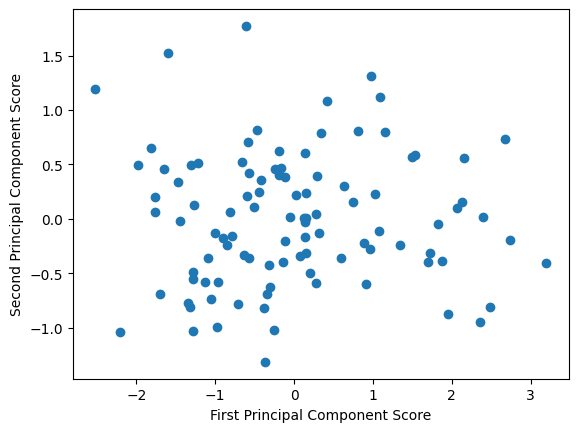

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

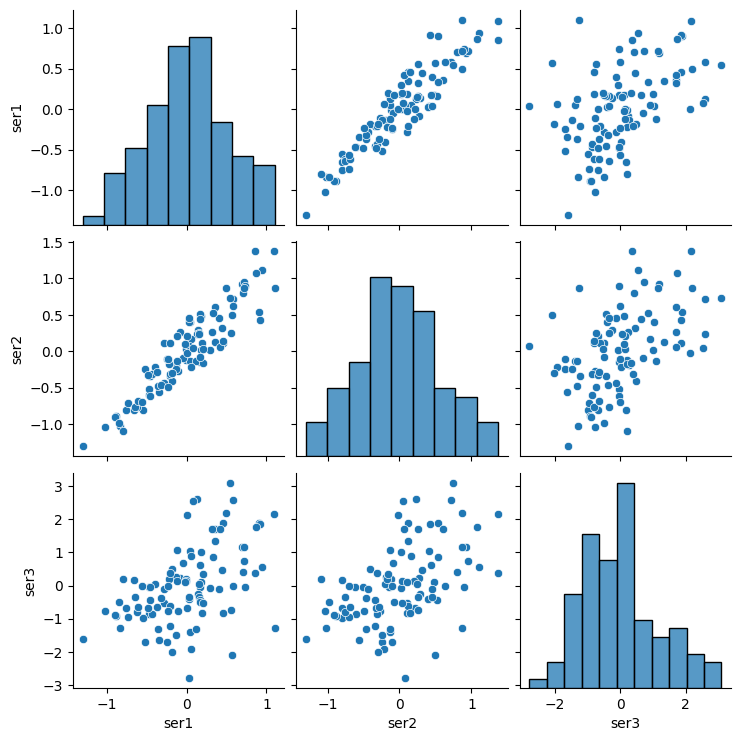

In [2]:
sns.pairplot(df)

## 2. Answer:  
The three outliers in the upper left corner have low first principal component scores and high second principal component scores.

The first principal component is mostly related to `series_3`, because the first component has the largest weight on `series_3`. So a low first principal component score suggests that these points have low values of `series_3`.

The second principal component has positive weights for `series_1` and `series_2`, and a negative weight for `series_3`. So a high second principal component score suggests that these points have relatively high values of `series_1` and `series_2` compared with `series_3`.

However, it is hard to say much about `series_1` and `series_2` separately from this graph. They both have similar positive weights in the second component, so the graph mainly shows their shared movement. It does not clearly show whether `series_1` is larger than `series_2`, or whether `series_2` is larger than `series_1`.

That difference is mostly captured by the third principal component, but the graph only shows the first two principal components. This is why it is almost impossible to say much about the relative values of `series_1` and `series_2` from this plot alone.

This also makes sense from how the data was created. `series_2` was created from `series_1` with only a small amount of noise, so `series_1` and `series_2` are strongly related and tend to move together. `series_3` was also created from `series_1`, but with much more noise, so it is less tightly related.

The pairplot helps make this clearer. It shows that `series_1` and `series_2` have a strong relationship, while `series_3` is more spread out and noisier. The pairplot is easier for seeing the original relationships between the variables.

The advantage of the PCA scatter plot is that it reduces three variables into two dimensions and makes unusual points easier to see. It is useful for spotting the three outliers in the upper left corner.

The disadvantage is that the axes are principal components, not the original variables. Each axis is a mixture of `series_1`, `series_2`, and `series_3`, so the graph is harder to interpret directly. It also does not show the third principal component, which is important for understanding the difference between `series_1` and `series_2`.

Overall, the PCA graph is useful for finding unusual points, especially points with low `series_3` compared with the other series. However, the pairplot is better for directly understanding the relationships between the original three series.


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## **Week 9 Analysis: Heatmaps, Bubble Plots, PCA, and Linear Regression**

### **Dataset 1: E-commerce User Behavior**

This section continues the analysis of Dataset 1 using the cleaned EDA version of the data. The Week 9 analysis focuses on heatmaps, bubble plots, Principal Component Analysis, and linear regression to better understand relationships among order value, engagement behavior, and add-to-cart activity.

#### **1.1 load and check**

In [3]:
# Load the cleaned dataset from the previous cleaning step
df_behavior = pd.read_pickle("data/df_behavior_eda.pkl")

# Quick check
df_behavior.shape

(51207, 27)

In [4]:
df_behavior.head(5)

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,...,140.0,2.0,0.05,46.0,4.6,Medium,14.7,1,1,1
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,...,211.0,3.0,0.03,112.0,11.2,Medium,15.0,0,0,1
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,...,117.0,5.0,0.01,31.2,3.1,Critical,19.9,1,1,1
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,...,118.0,2.0,0.05,26.2,2.6,High,15.8,1,1,1
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,...,250.0,1.0,0.04,160.0,16.0,Critical,18.1,1,1,1


In [5]:
df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51207 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          51207 non-null  object        
 1   Customer Name        51207 non-null  object        
 2   Segment              51207 non-null  object        
 3   City                 51207 non-null  object        
 4   State                51207 non-null  object        
 5   Country              51207 non-null  object        
 6   Region               51207 non-null  object        
 7   Gender               51207 non-null  object        
 8   Age                  51207 non-null  int64         
 9   Education            51207 non-null  object        
 10  Marital Status       51207 non-null  object        
 11  Order ID             51207 non-null  object        
 12  Order Date           51207 non-null  datetime64[ns]
 13  Months               51207 non-null 

#### **1.2 Selecting Variables for Analysis**

I selected variables that can be used for heatmaps, bubble plots, PCA, and linear regression. The goal is to keep the analysis focused on order value, customer engagement, and add-to-cart behavior.

In [6]:
# Select variables for analysis

numeric_cols_behavior = ["Age","Sales","Quantity","Discount","Profit","Shipping Cost","Browsing Time (min)","Like","Share","Add to Cart"]

categorical_cols_behavior = ["Segment","Region","Gender","Education","Marital Status","Ship Mode","Product Category","Order Priority"]

time_col_behavior = "Order Date"

print("Numeric columns:")
print(numeric_cols_behavior)

print("\nCategorical columns:")
print(categorical_cols_behavior)

print("\nTime column:")
print(time_col_behavior)

Numeric columns:
['Age', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Browsing Time (min)', 'Like', 'Share', 'Add to Cart']

Categorical columns:
['Segment', 'Region', 'Gender', 'Education', 'Marital Status', 'Ship Mode', 'Product Category', 'Order Priority']

Time column:
Order Date


The Week 9 analysis continues from the earlier EDA work, so the same main numeric, categorical, and time variables are kept for consistency. For specific analyses such as PCA or linear regression, smaller subsets of these variables will be created later.

#### **1.3 Heatmap Analysis**

Heatmaps are used to show patterns among several variables at the same time. The first heatmap shows correlations among numeric variables. The second heatmap shows how the Add to Cart rate changes across product categories and customer segments.

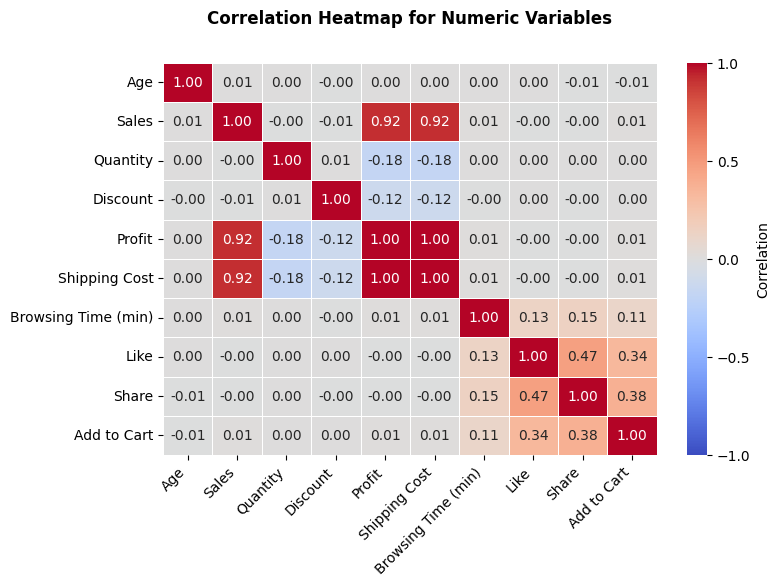

In [7]:
# Correlation heatmap for numeric variables

corr_behavior = df_behavior[numeric_cols_behavior].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_behavior,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0, cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Heatmap for Numeric Variables", fontweight="bold", pad=14, y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

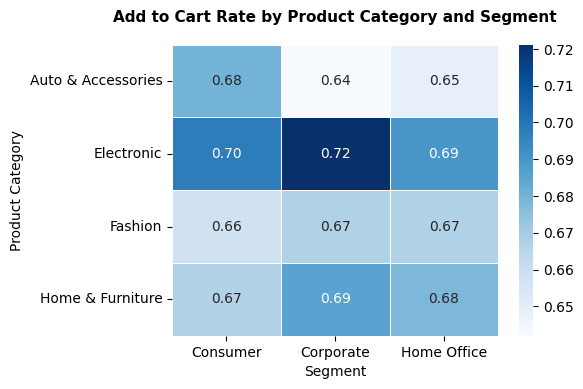

In [8]:
# Add to Cart rate heatmap by Product Category and Segment

add_to_cart_heatmap = df_behavior.pivot_table(index="Product Category", columns="Segment", values="Add to Cart",aggfunc="mean")

plt.figure(figsize=(6, 4))
sns.heatmap(add_to_cart_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5)

plt.title("Add to Cart Rate by Product Category and Segment", y=1.05, fontweight="bold", fontsize=11)
plt.xlabel("Segment")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

The Add to Cart rate is fairly close across most product categories and segments. Electronic products show the highest rates, especially in the Corporate segment, while Auto & Accessories has a lower rate for Corporate customers. Fashion is more stable across all segments. This suggests that Product Category and Segment may be related to add-to-cart behavior, but the differences are not large enough to fully explain purchase intent by themselves.

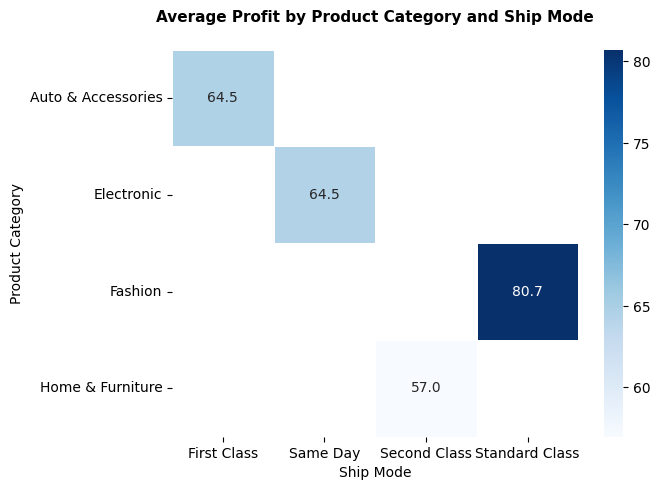

In [9]:
profit_heatmap = df_behavior.pivot_table(index="Product Category",columns="Ship Mode",values="Profit",aggfunc="mean")

plt.figure(figsize=(7, 5))
sns.heatmap(profit_heatmap,annot=True,cmap="Blues",fmt=".1f",linewidths=0.5)

plt.title("Average Profit by Product Category and Ship Mode", y=1.05, fontweight="bold", fontsize=11, x=0.5)
plt.xlabel("Ship Mode")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

This heatmap shows that Product Category and Ship Mode are highly structured in this dataset. Many product category and ship mode combinations do not appear in the data. Because of that, the average profit heatmap is sparse and should be interpreted carefully.

#### **1.4 Bubble Plot Analysis**

This bubble plot is used to compare three customer-behavior and business variables at the product category level. Each bubble represents one product category. The x-axis shows average browsing time, the y-axis shows Add to Cart rate, and the bubble size shows average Sales.

In [10]:
# Bubble plot by Product Category
bubble_behavior = df_behavior.groupby("Product Category").agg(
    avg_browsing_time=("Browsing Time (min)", "mean"),
    add_to_cart_rate=("Add to Cart", "mean"),
    avg_sales=("Sales", "mean")).reset_index()

bubble_behavior

,Product Category,avg_browsing_time,add_to_cart_rate,avg_sales
0,Auto & Accessories,15.852400,0.662923,146.126487
1,Electronic,16.307008,0.702633,146.123471
2,Fashion,17.523582,0.662284,169.373645
3,Home & Furniture,17.859773,0.674689,127.964577


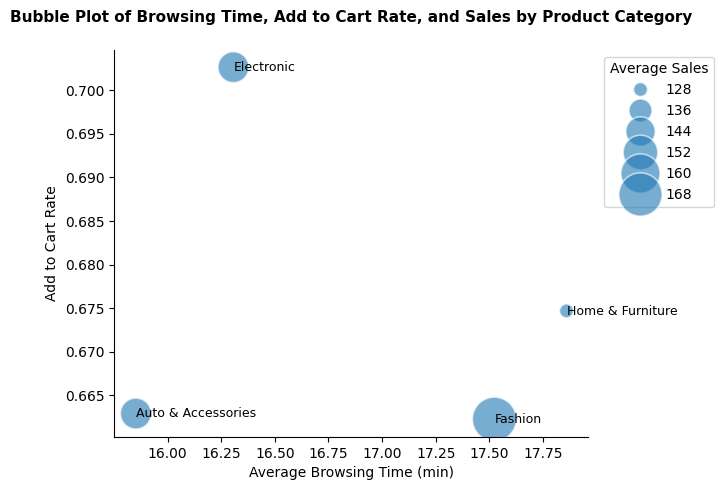

In [11]:
# Bubble plot: Browsing Time, Add to Cart Rate, and Sales

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=bubble_behavior,x="avg_browsing_time",y="add_to_cart_rate",size="avg_sales",sizes=(100, 1000),alpha=0.6,legend="brief")

for i, row in bubble_behavior.iterrows():
    ax.text(
        row["avg_browsing_time"],
        row["add_to_cart_rate"],
        row["Product Category"],
        ha="left",
        va="center",
        fontsize=9)

plt.title("Bubble Plot of Browsing Time, Add to Cart Rate, and Sales by Product Category", y=1.05, fontweight="bold", fontsize=11)
plt.xlabel("Average Browsing Time (min)")
plt.ylabel("Add to Cart Rate")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(title="Average Sales", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

This category-level bubble plot compares average Browsing Time, Add to Cart rate, and average Sales by Product Category. Electronic has the highest Add to Cart rate, even though its average browsing time is not the highest. Fashion and Home & Furniture have higher browsing times, but their Add to Cart rates are lower than Electronic. This suggests that longer browsing time alone does not fully explain purchase intent.

The bubble size adds average Sales to the plot. The larger bubbles do not perfectly match the highest Add to Cart rate, so average Sales also does not fully explain add-to-cart behavior by itself. Overall, this plot suggests that Product Category matters when comparing browsing behavior, sales value, and purchase intent.

#### **1.5 Principal Component Analysis**

Principal Component Analysis is used to check whether the numeric variables in Dataset 1 can be summarized with fewer dimensions. Since the variables have different scales, the data needs to be scaled before PCA.

In [12]:
# Import PCA and StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

For PCA, the main numeric variables are selected from the cleaned EDA dataset. These variables include financial features, customer behavior features, and engagement-related binary variables.

In [13]:
# Select numeric variables for PCA

pca_cols_behavior = ["Age","Sales","Quantity","Discount","Profit","Shipping Cost","Browsing Time (min)","Like","Share"]

X_pca_behavior = df_behavior[pca_cols_behavior].copy()
y_pca_behavior = df_behavior["Add to Cart"].copy()

X_pca_behavior.head()

,Age,Sales,Quantity,Discount,Profit,Shipping Cost,Browsing Time (min),Like,Share
0,22,140.0,2.0,0.05,46.0,4.6,14.7,1,1
1,32,211.0,3.0,0.03,112.0,11.2,15.0,0,0
2,21,117.0,5.0,0.01,31.2,3.1,19.9,1,1
3,22,118.0,2.0,0.05,26.2,2.6,15.8,1,1
4,28,250.0,1.0,0.04,160.0,16.0,18.1,1,1


In [14]:
# Scale the PCA data

scaler = StandardScaler()
X_pca_scaled_behavior  = scaler.fit_transform(X_pca_behavior)

In [15]:
# run PCA on the scaled data
pca_behavior = PCA()
pca_results_behavior = pca_behavior.fit_transform(X_pca_scaled_behavior )


In [16]:
# Explained variance table
explained_variance_behavior = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca_cols_behavior))],
    "Explained Variance Ratio": pca_behavior.explained_variance_ratio_,
    "Cumulative Explained Variance": pca_behavior.explained_variance_ratio_.cumsum()
})

explained_variance_behavior

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.325412,0.325412
1,PC2,0.171102,0.496515
2,PC3,0.111619,0.608134
3,PC4,0.111280,0.719414
4,PC5,0.110244,0.829658
5,PC6,0.103053,0.932710
6,PC7,0.059097,0.991807
7,PC8,0.008191,0.999998
8,PC9,0.000002,1.000000


In [17]:
# Create PCA loadings table

pca_loadings_behavior = pd.DataFrame(
    pca_behavior.components_.T,
    index=pca_cols_behavior,
    columns=[f"PC{i+1}" for i in range(len(pca_cols_behavior))]
)

pca_loadings_behavior.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Age,0.004,-0.008,-0.154,0.899,0.410,-0.019,0.012,-0.001,0.000
Sales,0.555,0.001,0.216,0.045,-0.022,-0.014,0.001,0.801,-0.001
Quantity,-0.107,0.009,0.699,0.380,-0.572,-0.072,0.000,-0.152,-0.000
Discount,-0.074,0.001,0.664,-0.207,0.706,0.050,0.007,-0.096,-0.000
Profit,0.581,-0.000,0.004,-0.003,0.002,-0.005,0.001,-0.402,0.708
Shipping Cost,0.581,-0.000,0.003,-0.003,0.002,-0.004,0.001,-0.404,-0.707
Browsing Time (min),0.009,0.343,0.013,0.054,-0.062,0.935,-0.025,0.001,0.000
Like,-0.001,0.662,-0.008,-0.005,0.030,-0.259,-0.703,-0.000,-0.000
Share,-0.002,0.667,-0.012,-0.016,0.014,-0.224,0.711,0.001,0.000


The PCA loadings show which original features contribute most to each principal component. PC1 is mainly driven by Sales, Profit, and Shipping Cost. This suggests that PC1 represents a financial or order-value direction in the data.

PC2 is mainly driven by Like and Share, with some contribution from Browsing Time. This suggests that PC2 represents an engagement direction. Add to Cart was not included as an input feature in the PCA because it is treated as the target-like variable. Instead, Add to Cart is used later only to color the PCA scatterplot and check whether the PCA directions show any separation in purchase-intent behavior.

Other variables are captured more strongly by later components. Quantity and Discount are more important in PC3 and PC5. Age is mostly related to PC4, and Browsing Time is most strongly related to PC6. This means that the first two principal components summarize the main financial and engagement patterns, but they do not fully explain all important parts of the dataset.

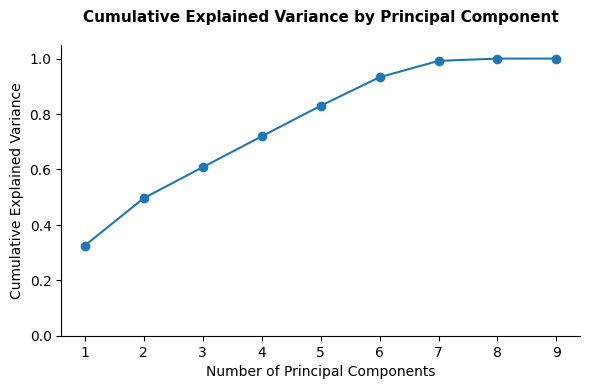

In [18]:
# Plot cumulative explained variance

plt.figure(figsize=(6, 4))

plt.plot(range(1, len(pca_behavior.explained_variance_ratio_) + 1),pca_behavior.explained_variance_ratio_.cumsum(),marker="o")

plt.title("Cumulative Explained Variance by Principal Component", y=1.05,fontsize=11, fontweight="bold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(pca_behavior.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The cumulative explained variance plot shows that the first one or two principal components do not capture enough of the total variation by themselves. PC1 explains about 32.5% of the variance, and PC1 plus PC2 explain about 49.7%. This means that reducing the dataset to only one principal component would lose too much information.

The curve increases gradually, which suggests that the dataset has several different sources of variation. Five components capture about 83.0% of the variance, and six components capture about 93.3%. Therefore, PCA can help summarize the data, but the first one or two components are not enough to fully represent this dataset.

In [19]:
# Create a dataframe with the first two principal component scores

pca_scores_behavior = pd.DataFrame(
    pca_results_behavior[:, :2],
    columns=["PC1", "PC2"],
    index=X_pca_behavior.index
)

pca_scores_behavior["Add to Cart"] = y_pca_behavior.loc[X_pca_behavior.index]

pca_scores_behavior.head()

,PC1,PC2,Add to Cart
0,-0.809469,1.147247,1
1,1.391447,-1.512835,1
2,-1.368287,1.347226,1
3,-1.465063,1.186160,1
4,2.949879,1.256982,1


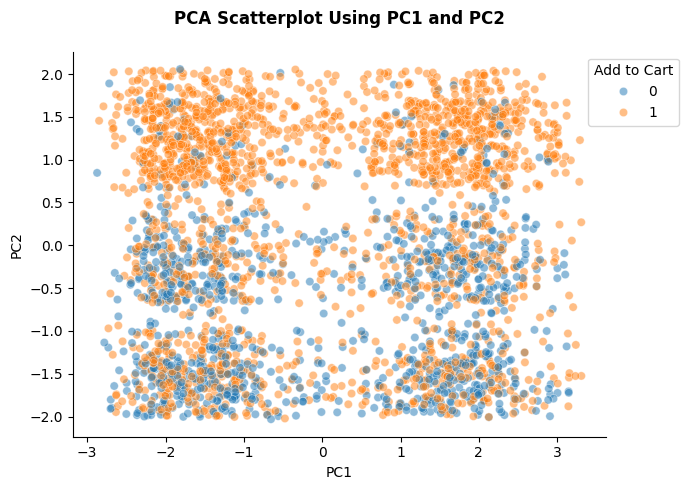

In [20]:
# PCA scatterplot using PC1 and PC2

pca_sample_behavior = pca_scores_behavior.sample(3000, random_state=42)

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(data=pca_sample_behavior,x="PC1", y="PC2",hue="Add to Cart",alpha=0.5)

plt.title("PCA Scatterplot Using PC1 and PC2", y=1.05, fontsize=12, fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(title="Add to Cart", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

The PCA scatterplot shows the first two principal components colored by Add to Cart. Add to Cart was not used as an input in the PCA, so the colors help show whether the other numeric features can separate add-to-cart behavior.

The plot shows some separation along PC2. Many Add to Cart = 1 points appear higher on PC2, while many Add to Cart = 0 points appear lower. However, the two groups still overlap a lot. This means PC1 and PC2 give some useful information, but they do not fully separate Add to Cart behavior.

#### **1.6 Linear Regression Analysis**

Linear regression is used to test which numeric variables can help predict other numeric variables. Based on the correlation heatmap, Sales, Profit, and Shipping Cost had the strongest relationships in Dataset 1. Because of that, these three variables are used for the regression analysis.

Similar to the Week 8 example, each variable is predicted using the other two variables. This helps compare which prediction works best and whether the strong correlations are useful for linear regression.

In [21]:
# Import tools for linear regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
# Linear regression using the strongest correlated numeric variables

variables_behavior = ["Sales", "Profit", "Shipping Cost"]

results_behavior = []

for target in variables_behavior:
    
    predictors = [col for col in variables_behavior if col != target]
    
    X = df_behavior[predictors]
    y = df_behavior[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_behavior.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse
    })

regression_results_behavior = pd.DataFrame(results_behavior)
regression_results_behavior

,target,predictors,test_r2_score,test_mse
0,Sales,"[Profit, Shipping Cost]",0.847255,662.690655
1,Profit,"[Sales, Shipping Cost]",0.999964,0.086250
2,Shipping Cost,"[Sales, Profit]",0.999964,0.000864


The linear regression results show that the strongest predictions happen when Profit or Shipping Cost is the target. Predicting Profit from Sales and Shipping Cost gives a test R2 score of about 1.00. Predicting Shipping Cost from Sales and Profit also gives a test R2 score of about 1.00. This means that these variables can be predicted very accurately from each other.

Predicting Sales from Profit and Shipping Cost also works well, with a test R2 score of about 0.85, but it is not as strong as the other two models.

These results match the correlation heatmap. Sales, Profit, and Shipping Cost had the strongest numeric relationships. However, the very high scores for Profit and Shipping Cost should be interpreted carefully because Profit and Shipping Cost were almost perfectly correlated. This suggests that these two variables may contain overlapping or redundant information.   

Overall, Sales, Profit, and Shipping Cost are the most useful numeric features for predicting each other in this dataset, but Profit and Shipping Cost may be too closely related to provide separate information.

#### **1.7 Final Week 9 Conclusion for Dataset 1**

The Week 9 analysis used heatmaps, a bubble plot, PCA, and linear regression to study relationships among the main variables in Dataset 1.

The heatmap analysis showed that Sales, Profit, and Shipping Cost have the strongest numeric relationships. Profit and Shipping Cost are almost perfectly correlated, which suggests that these two variables may contain overlapping information. The Add to Cart heatmap showed that Electronic products had higher add-to-cart rates, especially compared with some other product categories. However, the differences across product categories and segments were not very large.

The bubble plot showed that Electronic had the highest Add to Cart rate, even though it did not have the highest average browsing time. Fashion and Home & Furniture had higher average browsing times, but their Add to Cart rates were lower than Electronic. This suggests that longer browsing time alone does not fully explain purchase intent.

The PCA results showed that the first principal component mainly represents financial variables such as Sales, Profit, and Shipping Cost. The second component is more related to engagement variables such as Like and Share. PC1 explained about 29.3% of the variance, and PC1 plus PC2 explained about 47.8%. This means that one or two principal components can summarize part of the dataset, but they are not enough to fully represent it. About six components were needed to capture more than 85% of the variance.

The PCA scatterplot showed some separation between Add to Cart groups along PC2, but the groups still overlapped. This means the first two PCA components provide some useful information, but they do not fully separate add-to-cart behavior.

The linear regression results showed that Sales, Profit, and Shipping Cost are useful for predicting each other. Profit and Shipping Cost were predicted almost perfectly, but this result should be interpreted carefully because these two variables are almost perfectly correlated. This may indicate redundancy rather than a completely new insight.

Overall, Dataset 1 is usable for further analysis. The strongest patterns are found in the financial variables and engagement variables. However, Add to Cart behavior is not fully explained by one feature or by the first two PCA components. Future modeling should treat Add to Cart as a classification target and should handle redundant variables such as Profit and Shipping Cost carefully.

### **Dataset 2: Sales and Customer Insights**

This section continues the analysis of Dataset 2 using the cleaned EDA version of the data. The goal is to apply Week 9 methods, including heatmaps, bubble plots, PCA, and linear regression, while keeping the original readable columns for interpretation.

#### **2.1 load and check**

In [23]:
# Load the cleaned dataset from the previous cleaning step
df_sales = pd.read_pickle("data/df_sales_eda.pkl")

# Quick check
df_sales.shape

(10000, 15)

In [24]:
df_sales.head(5)

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [25]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_ID               10000 non-null  object        
 1   Product_ID                10000 non-null  object        
 2   Transaction_ID            10000 non-null  object        
 3   Purchase_Frequency        10000 non-null  int64         
 4   Average_Order_Value       10000 non-null  float64       
 5   Most_Frequent_Category    10000 non-null  object        
 6   Time_Between_Purchases    10000 non-null  int64         
 7   Region                    10000 non-null  object        
 8   Churn_Probability         10000 non-null  float64       
 9   Lifetime_Value            10000 non-null  float64       
 10  Launch_Date               10000 non-null  datetime64[ns]
 11  Peak_Sales_Date           10000 non-null  datetime64[ns]
 12  Season             

#### **2.2 Selecting Variables for Analysis**

For the analysis, the main numeric variables are selected for correlation heatmaps, PCA, and linear regression. The categorical variables are selected for grouped heatmaps or possible bubble plot summaries.

`Churn_Probability` is treated as the main target-like variable because it represents customer churn risk. For PCA, this variable should not be used as an input feature. It can be kept separate and used for interpretation or coloring the PCA plot.

In [26]:
# Select variables for Week 9 analysis

numeric_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]

categorical_cols_sales = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

date_cols_sales = ["Launch_Date","Peak_Sales_Date"]

target_like_sales = "Churn_Probability"

# PCA input columns should exclude the target-like variable
pca_input_cols_sales = [col for col in numeric_cols_sales if col != target_like_sales]

print("Numeric columns:")
print(numeric_cols_sales)

print("\nCategorical columns:")
print(categorical_cols_sales)

print("\nDate columns:")
print(date_cols_sales)

print("\nTarget-like variable:")
print(target_like_sales)

print("\nPCA input columns:")
print(pca_input_cols_sales)

print("\nMissing values in selected numeric columns:")
print(df_sales[numeric_cols_sales].isna().sum())

Numeric columns:
['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

Categorical columns:
['Most_Frequent_Category', 'Region', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy']

Date columns:
['Launch_Date', 'Peak_Sales_Date']

Target-like variable:
Churn_Probability

PCA input columns:
['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Lifetime_Value']

Missing values in selected numeric columns:
Purchase_Frequency        0
Average_Order_Value       0
Time_Between_Purchases    0
Churn_Probability         0
Lifetime_Value            0
dtype: int64


#### **2.3 Heatmap Analysis**


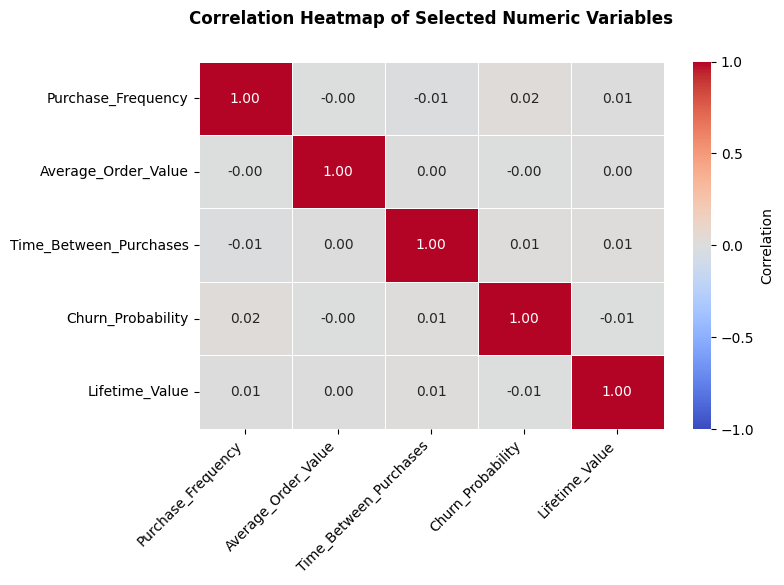

,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value
Purchase_Frequency,1.000000,-0.000072,-0.008885,0.018417,0.007010
Average_Order_Value,-0.000072,1.000000,0.004417,-0.000871,0.004184
Time_Between_Purchases,-0.008885,0.004417,1.000000,0.010410,0.010418
Churn_Probability,0.018417,-0.000871,0.010410,1.000000,-0.006847
Lifetime_Value,0.007010,0.004184,0.010418,-0.006847,1.000000


In [27]:
# Correlation heatmap for selected numeric variables

corr_sales = df_sales[numeric_cols_sales].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_sales,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0, cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})

plt.title("Correlation Heatmap of Selected Numeric Variables", fontweight="bold", pad=14, y=1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

corr_sales

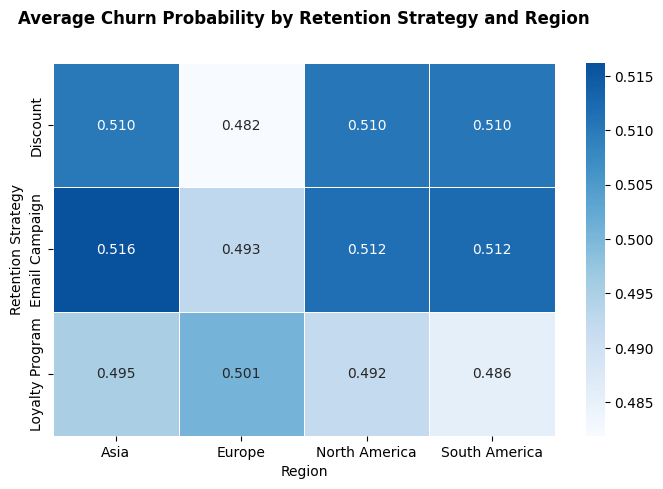

Region,Asia,Europe,North America,South America
Retention_Strategy,,,,
Discount,0.510204,0.481925,0.510409,0.510470
Email Campaign,0.516166,0.492540,0.511573,0.512363
Loyalty Program,0.495289,0.500626,0.492025,0.485570


In [28]:
# Grouped heatmap: average churn probability by retention strategy and region

churn_grouped_heatmap = df_sales.pivot_table(index="Retention_Strategy",columns="Region",values="Churn_Probability",aggfunc="mean")

plt.figure(figsize=(7, 5))
sns.heatmap(churn_grouped_heatmap,annot=True,cmap="Blues",center=df_sales["Churn_Probability"].mean(),fmt=".3f",linewidths=0.5)

plt.title("Average Churn Probability by Retention Strategy and Region",fontsize=12,fontweight="bold",pad=15, y=1.05)
plt.xlabel("Region")
plt.xticks(rotation=0, ha="center")
plt.ylabel("Retention Strategy")
plt.tight_layout()
plt.show()

churn_grouped_heatmap

The grouped heatmap shows that average `Churn_Probability` is very similar across retention strategies and regions. Most values are close to 0.50.

The highest value appears for Email Campaign in Asia, around 0.516, and the lowest value appears for Discount in Europe, around 0.482. However, this difference is small, so it should not be interpreted as a meaningful business pattern.

Overall, this heatmap does not show clear evidence that churn probability changes strongly by retention strategy or region. This supports the earlier finding that Dataset 2 has weak relationships and limited business insight.

#### **2.4 Bubble Plot Analysis**

In this step, a bubble plot is used to compare customer behavior and churn risk at the category level. Each bubble represents one product category. The x-axis shows average purchase frequency, the y-axis shows average churn probability, and bubble size represents average lifetime value.

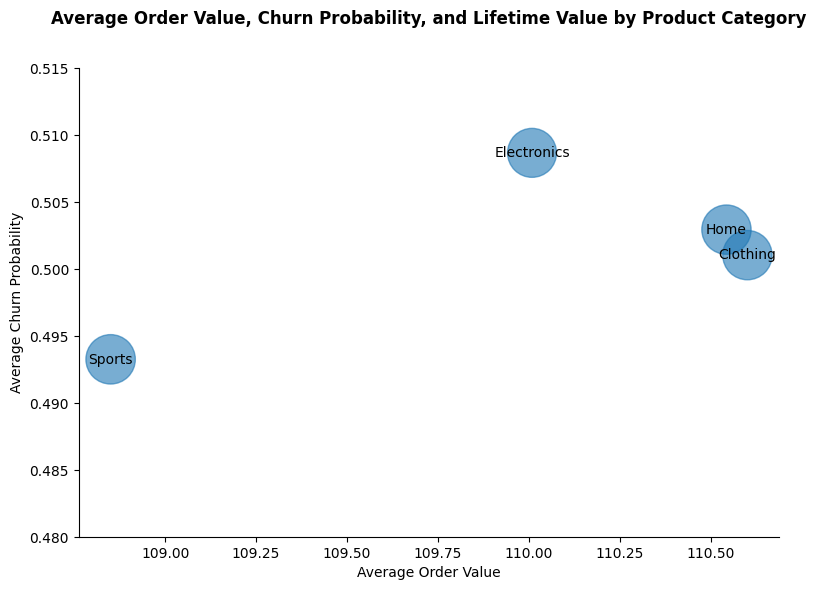

,Most_Frequent_Category,avg_order_value,avg_churn_probability,avg_lifetime_value
0,Clothing,110.600653,0.501024,5047.698829
1,Electronics,110.008543,0.508660,4973.470783
2,Home,110.543069,0.502928,5041.930477
3,Sports,108.850025,0.493245,5066.964548


In [29]:
# Simple bubble plot by product category

bubble_sales = (df_sales.groupby("Most_Frequent_Category").agg(
                                                            avg_order_value=("Average_Order_Value", "mean"),
                                                            avg_churn_probability=("Churn_Probability", "mean"),
                                                            avg_lifetime_value=("Lifetime_Value", "mean")).reset_index())

plt.figure(figsize=(8, 6))
plt.scatter(bubble_sales["avg_order_value"],bubble_sales["avg_churn_probability"],s=bubble_sales["avg_lifetime_value"] / 4,alpha=0.6)

# Add category labels
for i, row in bubble_sales.iterrows():
    plt.text(row["avg_order_value"],row["avg_churn_probability"], row["Most_Frequent_Category"],fontsize=10,ha="center",va="center")

plt.title("Average Order Value, Churn Probability, and Lifetime Value by Product Category",fontsize=12,fontweight="bold",pad=15, y=1.05)
plt.xlabel("Average Order Value")
plt.ylabel("Average Churn Probability")
plt.ylim(0.48, 0.515)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

bubble_sales

The bubble plot shows that the product categories are very close to each other. Average order value is around 109 to 111 for all categories, and average churn probability is close to 0.50.

Sports has slightly lower average order value and slightly lower average churn probability, while Electronics has slightly higher churn probability. However, these differences are small and should not be treated as strong business patterns.

The bubble sizes are also similar because average lifetime value is close across categories. Overall, this plot supports the earlier finding that Dataset 2 does not show clear separation between groups.

#### **2.5 Principal Component Analysis**

In this step, PCA is used to check whether the numeric features can be summarized using fewer dimensions. `Churn_Probability` is treated as the target-like variable, so it is not included as an input feature for PCA.

In [30]:
# Select PCA input columns
pca_input_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Lifetime_Value"]

# Scale PCA input features
scaler = StandardScaler()
X_sales_scaled = scaler.fit_transform(df_sales[pca_input_cols_sales])

# Run PCA
pca_sales = PCA()
X_sales_pca = pca_sales.fit_transform(X_sales_scaled)

# Explained variance table
explained_variance_sales = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca_input_cols_sales))],
    "Explained Variance Ratio": pca_sales.explained_variance_ratio_,
    "Cumulative Explained Variance": pca_sales.explained_variance_ratio_.cumsum()
})

explained_variance_sales


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.253354,0.253354
1,PC2,0.251751,0.505104
2,PC3,0.249300,0.754405
3,PC4,0.245595,1.000000


In [31]:
# PCA loadings table
pca_loadings_sales = pd.DataFrame(
    pca_sales.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_input_cols_sales))],
    index=pca_input_cols_sales
)

pca_loadings_sales.round(3)

,PC1,PC2,PC3,PC4
Purchase_Frequency,-0.154,0.828,-0.014,0.539
Average_Order_Value,0.408,0.101,0.907,-0.016
Time_Between_Purchases,0.687,-0.277,-0.268,0.616
Lifetime_Value,0.581,0.477,-0.324,-0.575


The PCA results show that the numeric features are not well summarized by only one principal component. PC1 captures about 25.3% of the variance, which is low. PC1 and PC2 together capture about 50.5% of the variance.

The explained variance is spread almost evenly across the four components. This means there is not one dominant direction that explains most of the data. This result matches the earlier correlation heatmap, where the numeric variables had very weak relationships with each other.

The PCA loadings show that PC1 is mainly related to `Time_Between_Purchases` and `Lifetime_Value`, while PC2 is mostly related to `Purchase_Frequency`. However, because the explained variance is spread so evenly, these components should be interpreted carefully.

Overall, PC1 alone is not enough to represent this dataset, and PC1 plus PC2 also do not provide a strong lower-dimensional summary.

In [32]:
pca_scores_sales = pd.DataFrame(X_sales_pca[:, :2], columns=["PC1", "PC2"])
pca_scores_sales["Churn_Probability"] = df_sales["Churn_Probability"].values
pca_scores_sales.head()

,PC1,PC2,Churn_Probability
0,-0.585131,0.519661,0.98
1,-1.411909,0.443612,0.66
2,-0.599418,-0.926494,0.60
3,-1.563711,0.674016,0.78
4,-1.065602,2.074427,0.52


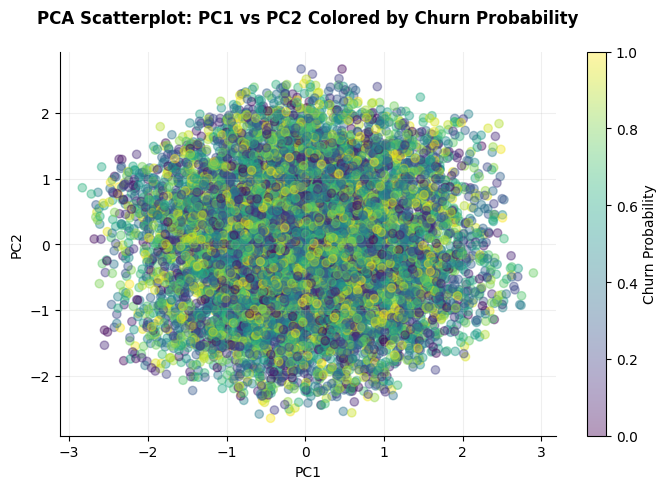

In [33]:
# PCA scatterplot: PC1 vs PC2 colored by churn probability
plt.figure(figsize=(7, 5))

scatter = plt.scatter(pca_scores_sales["PC1"],pca_scores_sales["PC2"],c=pca_scores_sales["Churn_Probability"],alpha=0.4)

plt.colorbar(scatter, label="Churn Probability")
plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Churn Probability",y=1.02,fontsize=12,fontweight="bold",pad=15)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The PCA scatterplot does not show clear separation based on `Churn_Probability`. The colors are mixed across the plot, which means customers with low and high churn probability are not separated well by PC1 and PC2.

This supports the explained variance result. PC1 captures only about 25.3% of the variance, and PC1 plus PC2 capture only about 50.5%. Therefore, the first two principal components do not provide a strong lower-dimensional representation of this dataset.

There are no obvious separated clusters in the PCA plot. This suggests that the numeric features do not form clear natural groups in this dataset.

#### **2.6 Linear Regression Analysis**

In this step, linear regression is used to test whether the selected numeric variables can predict each other. Based on the previous correlation heatmap, the relationships between numeric variables are very weak, so the regression results are expected to be limited.

In [34]:
regression_targets_sales = ["Churn_Probability","Lifetime_Value","Average_Order_Value"]

regression_results_sales = []

for target in regression_targets_sales:
    
    predictors = [col for col in numeric_cols_sales if col != target]
    
    X = df_sales[predictors]
    y = df_sales[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    regression_results_sales.append({
        "Target": target,
        "Predictors": ", ".join(predictors),
        "Test R2": r2,
        "Test MSE": mse
    })

regression_results_sales = pd.DataFrame(regression_results_sales)

regression_results_sales

,Target,Predictors,Test R2,Test MSE
0,Churn_Probability,"Purchase_Frequency, Average_Order_Value, Time_...",-0.002402,8.242790e-02
1,Lifetime_Value,"Purchase_Frequency, Average_Order_Value, Time_...",-0.001158,7.917642e+06
2,Average_Order_Value,"Purchase_Frequency, Time_Between_Purchases, Ch...",-0.002390,2.750367e+03


The linear regression results are very weak. All three models have negative test R2 values, which means the models do not predict the target variables better than a simple baseline using the average value.

`Churn_Probability`, `Lifetime_Value`, and `Average_Order_Value` were each tested as target variables, but the selected numeric predictors did not explain them well. This matches the earlier correlation heatmap, where the numeric variables had correlations close to 0.

Overall, the regression results suggest that the selected numeric features are not useful for predicting each other in Dataset 2. This supports the earlier finding that the dataset has limited analytical value and does not show meaningful business relationships.

#### **2.7 Final Week 9 Conclusion for Dataset 2**

The Week 9 analysis confirms that Dataset 2 has limited analytical value for finding meaningful business relationships.

The correlation heatmap showed that the selected numeric variables have very weak relationships with each other. There were no strong correlations and no clear redundant numeric variables.

The grouped heatmap of average `Churn_Probability` by `Retention_Strategy` and `Region` showed only small differences between groups. Most values were close to 0.50, so the differences should not be treated as meaningful business patterns.

The bubble plot also showed weak separation between product categories. Average order value, churn probability, and lifetime value were all very similar across categories. This suggests that product category does not clearly separate customer behavior in this dataset.

The PCA results showed that PC1 captured only about 25.3% of the variance, and PC1 and PC2 together captured only about 50.5%. This means PC1 alone is not enough to represent the dataset, and PC1 plus PC2 also do not provide a strong lower-dimensional summary. The explained variance was spread almost evenly across the components, which suggests that there is no dominant structure in the numeric features.

The PCA scatterplot did not show clear clusters or separation by `Churn_Probability`. Customers with different churn probabilities were mixed across the PCA space. This supports the idea that the numeric features do not form clear natural groups.

The linear regression results were also weak. All tested models had negative test R² values, meaning the selected numeric features did not predict `Churn_Probability`, `Lifetime_Value`, or `Average_Order_Value` better than a simple baseline.

Overall, Dataset 2 appears synthetic or artificially generated. The variables are too evenly distributed, the relationships between variables are very weak, and the analysis does not reveal useful business insight. The dataset is clean, but it is not very useful for explaining customer behavior, churn risk, customer value, or retention strategy. Any future modeling with this dataset should be interpreted very carefully.

### **Dataset 3: E-commerce Customer Churn Analysis and Prediction**

#### **3.1 load and check**

In [35]:
# Load the cleaned dataset from the previous cleaning step
df_churn = pd.read_pickle("data/df_churn_eda.pkl")

# Quick check
df_churn.shape

(5630, 20)

In [36]:
df_churn.head(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [37]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

#### **3.2 Selecting Variables for Analysis**

I selected variables that can be used for heatmaps, bubble plots, PCA, and linear regression.

`Churn` is the main target-like variable in this dataset. It will be used for interpretation, but it should not be included as an input feature for PCA.

In [38]:
# Select variables for Week 9 analysis

numeric_cols_churn = ["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered","SatisfactionScore","NumberOfAddress","Complain",
                      "OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Churn"]

pca_input_cols_churn = ["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered","SatisfactionScore","NumberOfAddress","Complain",
                        "OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount"]

categorical_cols_churn = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]

identifier_cols_churn = ["CustomerID"]

target_col_churn = "Churn"

date_cols_churn = []

print("Numeric columns:")
print(numeric_cols_churn)

print("\nPCA input columns:")
print(pca_input_cols_churn)

print("\nCategorical columns:")
print(categorical_cols_churn)

print("\nIdentifier columns:")
print(identifier_cols_churn)

print("\nTarget-like column:")
print(target_col_churn)

print("\nMissing values in selected numeric columns:")
print(df_churn[numeric_cols_churn].isna().sum().sort_values(ascending=False))

Numeric columns:
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']

PCA input columns:
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Identifier columns:
['CustomerID']

Target-like column:
Churn

Missing values in selected numeric columns:
DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
SatisfactionScore              

The selected numeric columns include customer tenure, order behavior, complaint status, satisfaction, cashback, delivery distance, and churn.

Several selected numeric columns still contain missing values. This is expected because the EDA version of the dataset keeps the original missing values for analysis.

For correlation analysis, the missing values can still be handled because the correlation calculation ignores missing pairs.

However, PCA and linear regression cannot use missing values directly. For those steps, a temporary numeric analysis dataset will be created using median imputation. This keeps the original EDA dataset unchanged while allowing PCA and regression to run correctly.

`Churn` is the main target-like variable. It will be included in the correlation heatmap, but it will be excluded from PCA input features because PCA should summarize input variables, not the target.

#### **3.3 Heatmap Analysis**

In this step, a correlation heatmap is used to examine relationships between selected numeric variables.

This heatmap helps identify strong relationships, weak relationships, possible redundant variables, and variables that may be useful for later linear regression analysis.

`Churn` is included in the heatmap because it is the main target-like variable. However, correlation should be interpreted carefully because it only shows association, not causation.

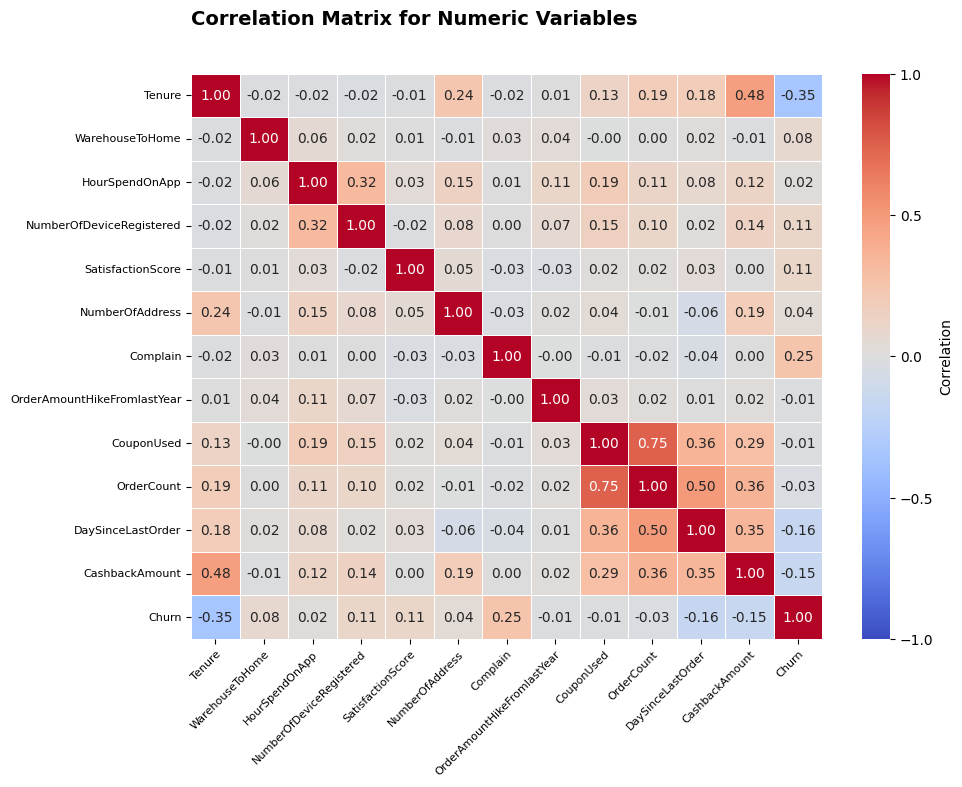

In [39]:
# Correlation heatmap for numeric variables

corr_churn = df_churn[numeric_cols_churn].corr()

# Heatmap of correlations

plt.figure(figsize=(10, 8))

ax = sns.heatmap(corr_churn,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

In [40]:
print("Correlations with Churn:")
display(corr_churn["Churn"].drop("Churn").sort_values(key=abs, ascending=False))

print("\nStrongest numeric correlations:")
corr_pairs = corr_churn.unstack().reset_index()
corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
corr_pairs = corr_pairs[corr_pairs["Variable_1"] < corr_pairs["Variable_2"]]
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()
display(corr_pairs.sort_values("Abs_Correlation", ascending=False).head(10))

Correlations with Churn:


Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
Name: Churn, dtype: float64


Strongest numeric correlations:


,Variable_1,Variable_2,Correlation,Abs_Correlation
113,CouponUsed,OrderCount,0.745245,0.745245
139,DaySinceLastOrder,OrderCount,0.497928,0.497928
143,CashbackAmount,Tenure,0.476380,0.476380
152,CashbackAmount,OrderCount,0.360984,0.360984
114,CouponUsed,DaySinceLastOrder,0.358930,0.358930
156,Churn,Tenure,-0.349408,0.349408
153,CashbackAmount,DaySinceLastOrder,0.347172,0.347172
29,HourSpendOnApp,NumberOfDeviceRegistered,0.316800,0.316800
151,CashbackAmount,CouponUsed,0.286728,0.286728
162,Churn,Complain,0.250188,0.250188


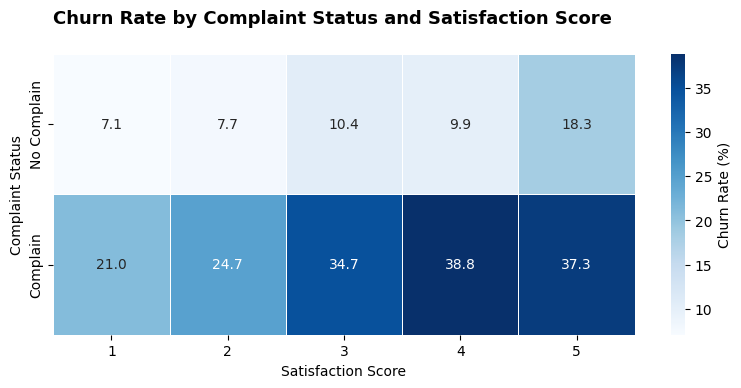

In [41]:
# Grouped heatmap for churn rate by Complain and SatisfactionScore

churn_group_heatmap = df_churn.pivot_table(values="Churn",index="Complain",columns="SatisfactionScore",aggfunc="mean") * 100

churn_group_heatmap.index = churn_group_heatmap.index.map({0: "No Complain", 1: "Complain"})

plt.figure(figsize=(8, 4))

ax = sns.heatmap(churn_group_heatmap,annot=True,fmt=".1f",cmap="Blues",linewidths=0.5,cbar_kws={"label": "Churn Rate (%)"})

ax.set_title("Churn Rate by Complaint Status and Satisfaction Score", loc="left", fontsize=13, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Complaint Status")

plt.tight_layout()
plt.show()

The grouped heatmap shows that complaint status is strongly related to churn rate.

Customers with no complaint have much lower churn rates across all satisfaction scores. Their churn rate ranges from about 7% to 18%.

Customers who complained have much higher churn rates across all satisfaction scores. Their churn rate ranges from about 21% to almost 39%.

This suggests that complaint status may be more important than satisfaction score by itself. Within both complaint groups, higher satisfaction scores do not always mean lower churn. This pattern should be interpreted carefully because the heatmap shows association, not causation.

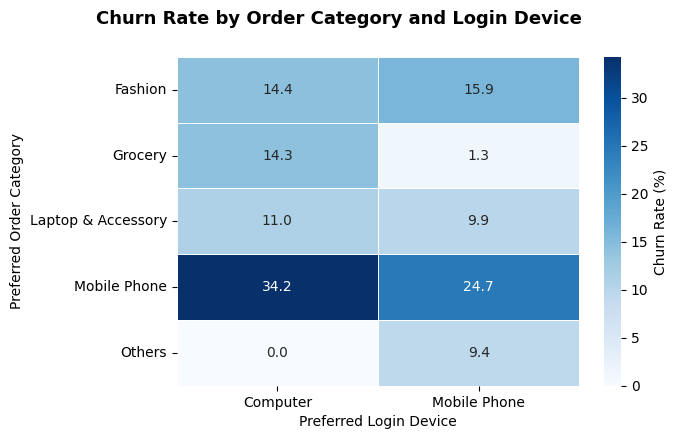

In [42]:
# Grouped heatmap for churn rate by preferred order category and login device

order_device_churn_heatmap = df_churn.pivot_table(values="Churn",index="PreferedOrderCat",columns="PreferredLoginDevice",aggfunc="mean") * 100

plt.figure(figsize=(7, 4.5))

ax = sns.heatmap(order_device_churn_heatmap,annot=True,fmt=".1f",cmap="Blues",linewidths=0.5,cbar_kws={"label": "Churn Rate (%)"})

ax.set_title("Churn Rate by Order Category and Login Device",loc="left",fontsize=13,fontweight="bold",pad=12, x=-0.2, y=1.05)
ax.set_xlabel("Preferred Login Device")
ax.set_ylabel("Preferred Order Category")

plt.tight_layout()
plt.show()

The grouped heatmap shows churn rate across preferred order category and preferred login device.

`Mobile Phone` as an order category has the highest churn rate in both login-device groups. The churn rate is especially high for customers who prefer `Mobile Phone` orders and use `Computer` as their login device.

Other categories, such as `Laptop & Accessory`, show lower churn rates across both login-device groups.

This heatmap suggests that churn may vary by both product-interest group and login device. However, some values should be interpreted carefully because small group sizes can make churn rates look unusually high or low.

#### **3.4 Bubble Plot Analysis**


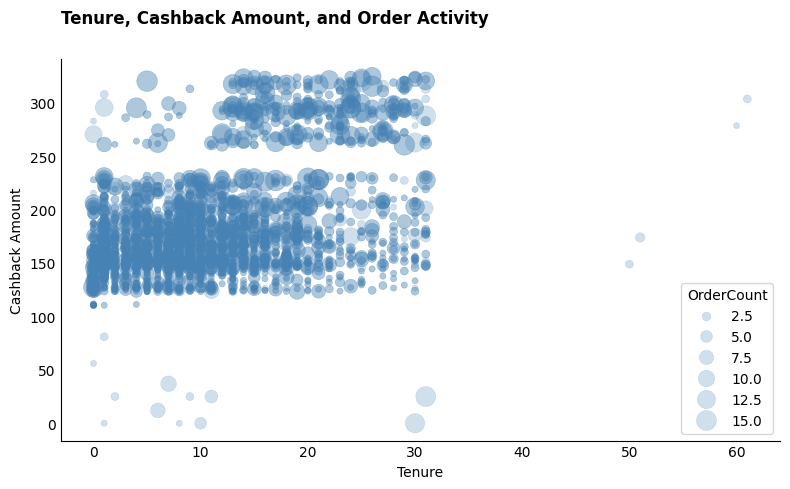

In [43]:
# Row-level bubble plot for Tenure, Cashback Amount, and Order Count

bubble_row_churn = df_churn[["Tenure", "CashbackAmount", "OrderCount"]].dropna().copy()

plt.figure(figsize=(8, 5))

ax = sns.scatterplot(data=bubble_row_churn,x="Tenure",y="CashbackAmount",size="OrderCount",sizes=(20, 220),
                     alpha=0.25,color="steelblue",edgecolor=None,legend="brief")

ax.set_title("Tenure, Cashback Amount, and Order Activity", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Tenure")
ax.set_ylabel("Cashback Amount")
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The bubble plot shows the relationship between customer tenure, cashback amount, and order count.

Most customers are concentrated at lower to middle tenure values, with cashback amounts mostly between about 120 and 230.

There is a visible positive pattern between `Tenure` and `CashbackAmount`, but the relationship is not perfectly linear. Some customers with longer tenure have higher cashback amounts.

Bubble size represents `OrderCount`. Larger bubbles appear in different parts of the plot, which suggests that order activity varies across customers.

The plot also shows a few unusual points, including customers with very high tenure values and a few customers with very low cashback amounts. These points should be interpreted carefully, but they may represent real customer behavior.

#### **3.5 Principal Component Analysis**

In this step, PCA is used to check whether the numeric features can be summarized with fewer dimensions.

`Churn` is not included as a PCA input because it is the target-like variable.

Since PCA cannot use missing values directly, a temporary numeric copy is created and missing values are filled with the median. The original dataset is not changed.

The features are also scaled before PCA because PCA is sensitive to different variable scales.

In [44]:
# Principal Component Analysis 

pca_data_churn = df_churn[pca_input_cols_churn].copy()
pca_data_churn_imputed = pca_data_churn.fillna(pca_data_churn.median())

scaler = StandardScaler()
pca_scaled_churn = scaler.fit_transform(pca_data_churn_imputed)

pca_churn = PCA()
pca_scores_churn = pca_churn.fit_transform(pca_scaled_churn)

explained_variance_churn = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca_input_cols_churn))],
    "Explained_Variance_Ratio": pca_churn.explained_variance_ratio_,
    "Cumulative_Explained_Variance": pca_churn.explained_variance_ratio_.cumsum()})

display(explained_variance_churn)

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.198696,0.198696
1,PC2,0.113409,0.312104
2,PC3,0.111487,0.423591
3,PC4,0.087615,0.511206
4,PC5,0.083978,0.595185
5,PC6,0.082694,0.677878
6,PC7,0.077343,0.755222
7,PC8,0.067754,0.822975
8,PC9,0.058483,0.881458
9,PC10,0.051070,0.932529


In [45]:
pca_loadings_churn = pd.DataFrame(
    pca_churn.components_.T,
    index=pca_input_cols_churn,
    columns=[f"PC{i+1}" for i in range(len(pca_input_cols_churn))])

display(pca_loadings_churn.round(3))
print("Top PC1 loadings:")
display(pca_loadings_churn[["PC1"]].sort_values("PC1", key=abs, ascending=False))

print("Top PC2 loadings:")
display(pca_loadings_churn[["PC2"]].sort_values("PC2", key=abs, ascending=False))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Tenure,0.308,-0.298,0.504,-0.148,0.037,-0.089,0.030,-0.104,-0.110,-0.384,-0.599,0.033
WarehouseToHome,0.016,0.173,-0.037,-0.256,0.809,-0.216,-0.410,0.141,-0.114,0.006,0.009,-0.002
HourSpendOnApp,0.206,0.595,0.055,0.081,-0.006,0.078,-0.073,-0.105,0.653,-0.368,-0.041,0.084
NumberOfDeviceRegistered,0.182,0.568,0.052,0.008,-0.200,0.140,-0.205,-0.367,-0.549,0.259,-0.190,0.023
SatisfactionScore,0.027,0.011,0.026,0.698,0.491,0.189,0.412,-0.193,-0.151,-0.070,-0.013,-0.003
NumberOfAddress,0.133,0.151,0.601,0.157,-0.004,0.070,0.043,0.564,0.107,0.485,0.025,0.046
Complain,-0.028,0.061,-0.025,-0.564,0.206,0.670,0.422,-0.003,0.029,0.068,-0.040,0.010
OrderAmountHikeFromlastYear,0.031,0.303,-0.007,-0.239,0.009,-0.641,0.655,-0.007,-0.080,0.043,0.036,-0.006
CouponUsed,0.461,0.071,-0.327,0.062,-0.072,0.082,0.042,0.432,-0.151,-0.183,-0.069,-0.640
OrderCount,0.500,-0.085,-0.326,0.024,-0.033,0.027,0.041,0.249,-0.136,-0.056,0.074,0.737


Top PC1 loadings:


,PC1
OrderCount,0.500123
CouponUsed,0.460623
CashbackAmount,0.436753
DaySinceLastOrder,0.394979
Tenure,0.308076
HourSpendOnApp,0.205848
NumberOfDeviceRegistered,0.182293
NumberOfAddress,0.132997
OrderAmountHikeFromlastYear,0.030970
Complain,-0.027989


Top PC2 loadings:


,PC2
HourSpendOnApp,0.595316
NumberOfDeviceRegistered,0.567586
OrderAmountHikeFromlastYear,0.302800
Tenure,-0.297856
DaySinceLastOrder,-0.229991
WarehouseToHome,0.172718
NumberOfAddress,0.150739
CashbackAmount,-0.146749
OrderCount,-0.085363
CouponUsed,0.070568


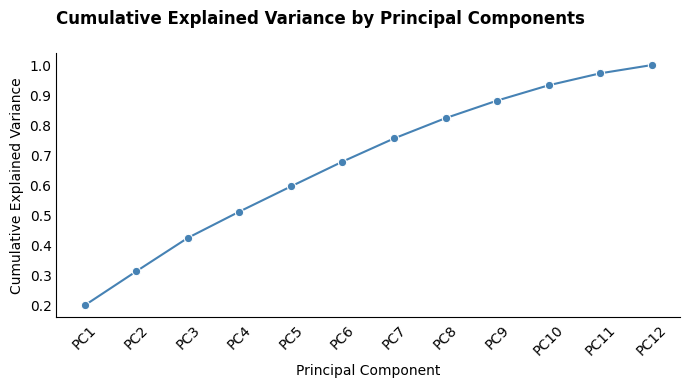

In [46]:
plt.figure(figsize=(7, 4))

ax = sns.lineplot(data=explained_variance_churn,x="Principal_Component",y="Cumulative_Explained_Variance",marker="o",color="steelblue")

ax.set_title("Cumulative Explained Variance by Principal Components", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.tick_params(axis="x", rotation=45, length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
pca_scores_df_churn = pd.DataFrame(pca_scores_churn[:, :2],columns=["PC1", "PC2"],index=df_churn.index)

pca_scores_df_churn["Churn"] = df_churn["Churn"]
pca_scores_df_churn["Churn_Label"] = pca_scores_df_churn["Churn"].map({0: "No Churn", 1: "Churn"})

pca_scores_df_churn

,PC1,PC2,Churn,Churn_Label
0,-0.819921,-0.286182,1,Churn
1,-1.650141,0.760567,1,Churn
2,-1.632327,0.037949,1,Churn
3,-1.589569,0.764935,1,Churn
4,-1.634329,-0.259990,1,Churn
...,...,...,...,...
5625,-0.799863,-0.222300,0,No Churn
5626,0.420255,0.688819,0,No Churn
5627,-0.984054,-0.164956,0,No Churn
5628,1.445023,0.673065,0,No Churn


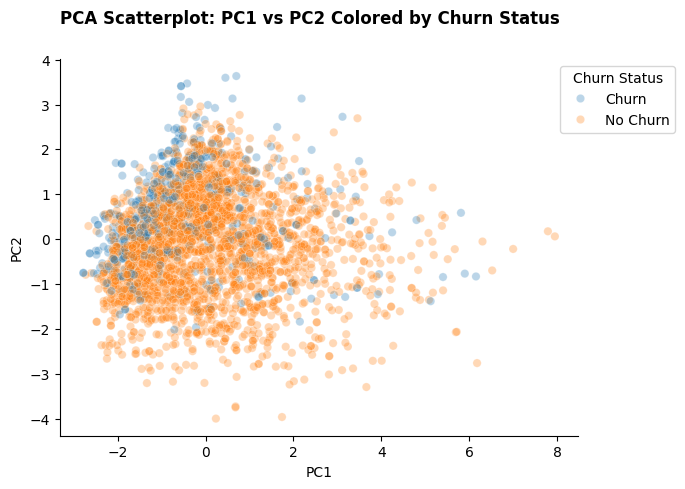

In [48]:
plt.figure(figsize=(7, 5))
pca_sample_churn = pca_scores_df_churn.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_sample_churn,x="PC1",y="PC2",hue="Churn_Label",alpha=0.3)

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Churn Status", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Churn Status", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

The PCA results show that the first principal component does not capture most of the dataset variance.

PC1 captures about 19.9% of the variance. PC1 and PC2 together capture about 31.2% of the variance. This means PC1 alone is not enough to represent the dataset, and PC1 and PC2 together also do not give a strong lower-dimensional summary.

The cumulative explained variance reaches about 88.1% at PC9. This suggests that several components are needed to represent most of the numeric information in this dataset.

The PC1 loadings are mainly related to `OrderCount`, `CouponUsed`, `CashbackAmount`, `DaySinceLastOrder`, and `Tenure`. This suggests that PC1 is mostly connected to customer order activity, cashback, and tenure-related behavior.

The PC2 loadings are mostly related to `HourSpendOnApp`, `NumberOfDeviceRegistered`, `OrderAmountHikeFromlastYear`, and `Tenure`. This suggests that PC2 may be more related to app/device activity and some customer behavior patterns.

The PC1 vs PC2 scatterplot shows heavy overlap between churned and non-churned customers. There is no clear separation between the two churn groups. A few points appear farther away from the main cluster, especially on the PC1 axis, which may reflect unusual customer behavior.

Overall, PCA helps summarize some structure in the data, but it does not show that Dataset 3 can be represented well using only one or two principal components.

#### **3.6 Linear Regression Analysis**

In this step, linear regression is used to test whether the strongest related numeric variables can predict each other.

The selected variables are based on the correlation heatmap results.

`Churn` is not used as the regression target here because it is a binary classification target. Linear regression is used only for numeric targets in this section.

Because some selected numeric columns have missing values, a temporary copy is created and missing values are filled with the median. The original dataset is not changed.

In [49]:
# Linear regression using the strongest correlated numeric variables

variables_churn = [ "CouponUsed","OrderCount","DaySinceLastOrder","CashbackAmount","Tenure"]

regression_data_churn = df_churn[variables_churn].copy()
regression_data_churn = regression_data_churn.fillna(regression_data_churn.median())

results_churn = []

for target in variables_churn:
    
    predictors = [col for col in variables_churn if col != target]
    
    X = regression_data_churn[predictors]
    y = regression_data_churn[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_churn.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse})

regression_results_churn = pd.DataFrame(results_churn)
regression_results_churn

,target,predictors,test_r2_score,test_mse
0,CouponUsed,"[OrderCount, DaySinceLastOrder, CashbackAmount...",0.372836,2.183161
1,OrderCount,"[CouponUsed, DaySinceLastOrder, CashbackAmount...",0.451235,4.473137
2,DaySinceLastOrder,"[CouponUsed, OrderCount, CashbackAmount, Tenure]",0.195694,10.692776
3,CashbackAmount,"[CouponUsed, OrderCount, DaySinceLastOrder, Te...",0.273334,1783.052337
4,Tenure,"[CouponUsed, OrderCount, DaySinceLastOrder, Ca...",0.187114,53.747064


The linear regression results show that some numeric variables can predict each other better than others.

The best result is for predicting `OrderCount`, with a test R2 of about 0.45. This means the selected predictors explain about 45% of the variation in `OrderCount` on the test data.

The next strongest result is for predicting `CouponUsed`, with a test R2 of about 0.37. This matches the correlation heatmap because `CouponUsed` and `OrderCount` had the strongest relationship.

The models for `CashbackAmount`, `DaySinceLastOrder`, and `Tenure` have lower R2 values. These variables have some relationship with the selected predictors, but the relationships are not strong enough for highly accurate prediction.

Overall, the linear regression results support the heatmap findings. `OrderCount` and `CouponUsed` appear to be the most connected variables in this group, while the other variables are only moderately or weakly predicted.

These results should be interpreted as association, not causation.

#### **3.7 Final Week 9 Conclusion for Dataset 3**

The Week 9 analysis shows that Dataset 3 has some useful structure, but the relationships are not strong enough to summarize the full dataset with only one or two variables.

The correlation heatmap showed that most numeric relationships are weak to moderate. The strongest relationship was between `CouponUsed` and `OrderCount`. Other useful relationships included `OrderCount` with `DaySinceLastOrder`, and `Tenure` with `CashbackAmount`.

The grouped heatmaps showed more useful churn-related patterns. Complaint status was strongly related to churn rate. Customers who complained had much higher churn rates than customers who did not complain. The heatmap by preferred order category and login device also showed that churn rate can vary across customer behavior groups, but some values should be interpreted carefully because group sizes may affect the percentages.

The bubble plot showed a visible relationship between `Tenure`, `CashbackAmount`, and `OrderCount`. Customers with longer tenure tended to have higher cashback amounts, but the pattern was not perfectly linear. The plot also showed some unusual points, including customers with very high tenure or very low cashback amounts.

The PCA results showed that PC1 captured about 19.9% of the variance. PC1 and PC2 together captured about 31.2% of the variance. This means PC1 alone is not enough to represent the dataset, and PC1 and PC2 together are also not enough for a strong lower-dimensional summary.

The cumulative explained variance reached about 88.1% at PC9. This suggests that several components are needed to represent most of the numeric information in Dataset 3.

The PCA loadings showed that PC1 was mainly related to order activity and customer value variables, such as `OrderCount`, `CouponUsed`, `CashbackAmount`, `DaySinceLastOrder`, and `Tenure`. PC2 was more related to app and device behavior, including `HourSpendOnApp` and `NumberOfDeviceRegistered`.

The PC1 vs PC2 scatterplot showed heavy overlap between churned and non-churned customers. There was no clear separation between the two groups, so the first two principal components do not provide a strong churn-separation view.

The linear regression results supported the heatmap findings. The best regression result was for predicting `OrderCount`, with a test R² of about 0.45. Predicting `CouponUsed` also had a moderate result, with a test R² of about 0.37. These results match the strong relationship between `CouponUsed` and `OrderCount` in the correlation heatmap.

The regression models for `CashbackAmount`, `DaySinceLastOrder`, and `Tenure` were weaker. These variables have some relationship with the selected predictors, but they are not highly predictable using simple linear regression.

Overall, Dataset 3 is usable and meaningful for customer churn analysis. It has a clear target-like variable, useful customer behavior variables, and several interpretable churn-related patterns. However, the dataset also has missing values, class imbalance, overlapping churn groups, and limited PCA separation. Future modeling should handle these issues carefully and should use classification methods for `Churn` instead of linear regression.

### **Dataset 4: E-Commerce Customer Behavior and Sales Analysis - TR**

#### **4.1 load and check**

In [50]:
# Load the cleaned dataset from the previous cleaning step
df_purchase_experience = pd.read_pickle("data/df_purchase_experience_eda.pkl")

# Quick check
df_purchase_experience.shape

(5000, 18)

In [51]:
df_purchase_experience.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [52]:
df_purchase_experience.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

#### **4.2 Selecting Variables for Week 9 Analysis**

I selected variables, identifier columns, date columns, and target-like variables before creating heatmaps, bubble plots, PCA, and regression models.

For Dataset 4, `Total_Amount` can be used as a sales/value target-like variable, and `Customer_Rating` can be used as a customer experience target-like variable. Identifier columns are not used as main analysis variables.

In [53]:
numeric_cols_purchase = ["Age","Unit_Price","Quantity","Discount_Amount","Total_Amount",
                         "Session_Duration_Minutes","Pages_Viewed","Delivery_Time_Days","Customer_Rating"]

categorical_cols_purchase = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]

identifier_cols_purchase = ["Order_ID","Customer_ID"]

date_col_purchase = "Date"

target_like_cols_purchase = ["Total_Amount","Customer_Rating","Is_Returning_Customer"]

print("Numeric columns:")
print(numeric_cols_purchase)

print("\nCategorical columns:")
print(categorical_cols_purchase)

print("\nIdentifier columns:")
print(identifier_cols_purchase)

print("\nDate column:")
print(date_col_purchase)

print("\nTarget-like variables:")
print(target_like_cols_purchase)

Numeric columns:
['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']

Categorical columns:
['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type', 'Is_Returning_Customer']

Identifier columns:
['Order_ID', 'Customer_ID']

Date column:
Date

Target-like variables:
['Total_Amount', 'Customer_Rating', 'Is_Returning_Customer']


#### **4.3 Heatmap Analysis**

In this step, a correlation heatmap is used to examine relationships between selected numeric variables.

This heatmap helps identify strong relationships, weak relationships, possible redundant variables, and variables that may be useful for later linear regression analysis.

`Total_Amount` and `Customer_Rating` are included because they are important target-like variables for this dataset. `Total_Amount` is related to sales value, and `Customer_Rating` is related to customer experience. However, correlation should be interpreted carefully because it only shows association, not causation.

In [54]:
corr_purchase = df_purchase_experience[numeric_cols_purchase].corr()

corr_purchase

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
Age,1.000000,-0.001618,0.000131,-0.012163,-0.004473,0.001897,-0.006434,-0.017105,-0.010401
Unit_Price,-0.001618,1.000000,-0.004005,0.449766,0.791073,-0.010063,0.004763,-0.005888,0.006185
Quantity,0.000131,-0.004005,1.000000,0.014404,0.329053,-0.006383,-0.004417,-0.004569,-0.015598
Discount_Amount,-0.012163,0.449766,0.014404,1.000000,0.347578,-0.001656,0.009103,-0.019653,0.013526
Total_Amount,-0.004473,0.791073,0.329053,0.347578,1.000000,-0.004119,-0.011831,-0.005893,0.005742
Session_Duration_Minutes,0.001897,-0.010063,-0.006383,-0.001656,-0.004119,1.000000,0.023923,0.015044,0.025725
Pages_Viewed,-0.006434,0.004763,-0.004417,0.009103,-0.011831,0.023923,1.000000,0.002002,0.007479
Delivery_Time_Days,-0.017105,-0.005888,-0.004569,-0.019653,-0.005893,0.015044,0.002002,1.000000,-0.009948
Customer_Rating,-0.010401,0.006185,-0.015598,0.013526,0.005742,0.025725,0.007479,-0.009948,1.000000


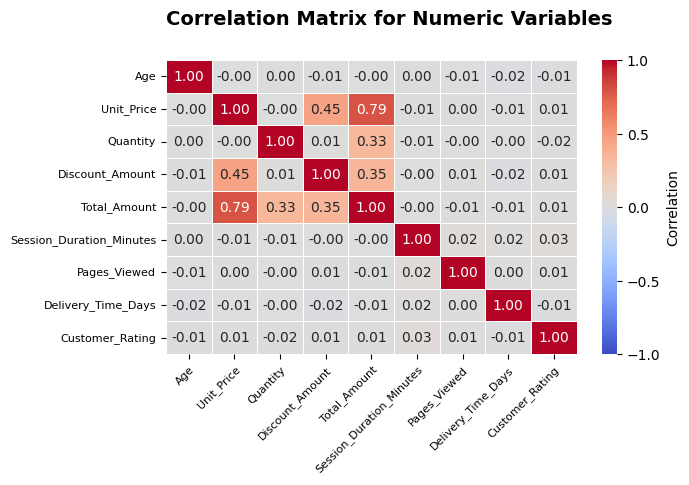

In [55]:
# Heatmap of correlations
plt.figure(figsize=(7, 5))

ax = sns.heatmap(corr_purchase ,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1,center=0,cbar_kws={"label": "Correlation", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor",fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)

plt.title("Correlation Matrix for Numeric Variables",loc="left",fontsize=14,fontweight="bold",pad=15,y=1.05,x=0)
plt.tight_layout()
plt.show()

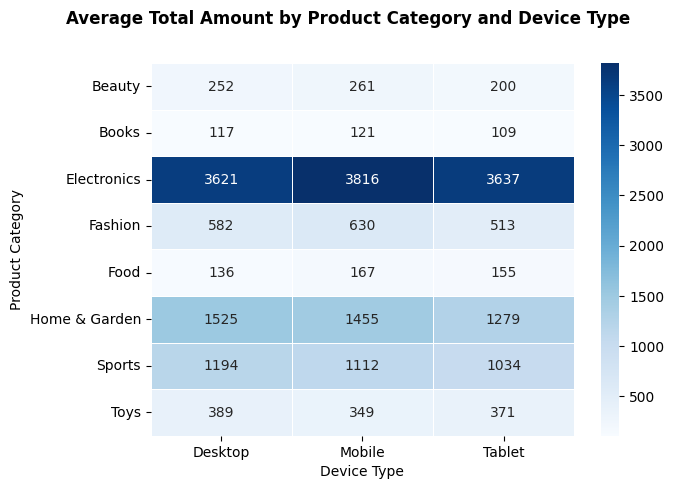

In [56]:
avg_amount_heatmap = (df_purchase_experience.pivot_table(values="Total_Amount",index="Product_Category",columns="Device_Type",aggfunc="mean" ))

plt.figure(figsize=(7, 5))

sns.heatmap(avg_amount_heatmap,annot=True,cmap="Blues",fmt=".0f",linewidths=0.5)

plt.title("Average Total Amount by Product Category and Device Type", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.2, y=1.05)
plt.xlabel("Device Type")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

The heatmap shows that Electronics has the highest average total amount across all device types. Home & Garden and Sports also have relatively higher order values compared with other categories. Books and Food have the lowest average total amounts.

However, this plot should be interpreted carefully because some product categories may naturally have higher prices. For example, Electronics may have a higher total amount mainly because electronics products are more expensive.

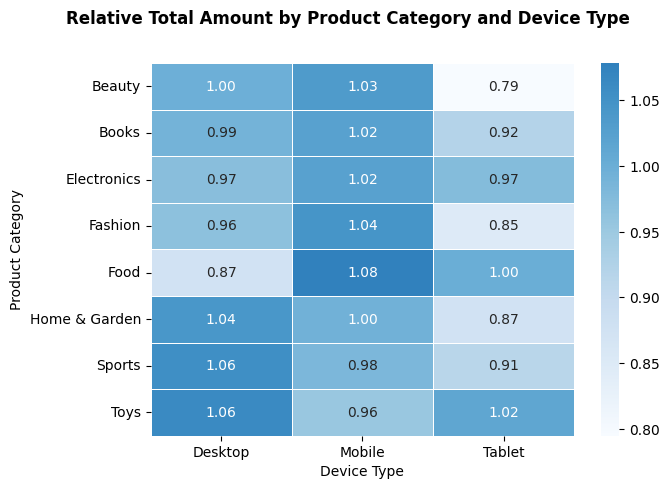

In [57]:
plot_df = df_purchase_experience.copy()

category_avg_amount = plot_df.groupby("Product_Category")["Total_Amount"].transform("mean")

plot_df["Relative_Total_Amount"] = plot_df["Total_Amount"] / category_avg_amount

relative_amount_heatmap = (plot_df.pivot_table(values="Relative_Total_Amount",index="Product_Category",
                                               columns="Device_Type",aggfunc="mean"))
plt.figure(figsize=(7, 5))

sns.heatmap(relative_amount_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5,center=1)

plt.title("Relative Total Amount by Product Category and Device Type", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.2, y=1.05)
plt.xlabel("Device Type")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

This heatmap gives a fairer comparison because each product category is compared with its own average. Most values are close to 1, which means device type does not create a very large difference in order value within most categories.

Some patterns still appear. Mobile is slightly higher than the category average for Food, Fashion, Beauty, Books, and Electronics. Desktop is slightly higher for Home & Garden, Sports, and Toys. Tablet is lower than the category average for several categories, especially Beauty, Fashion, and Home & Garden.

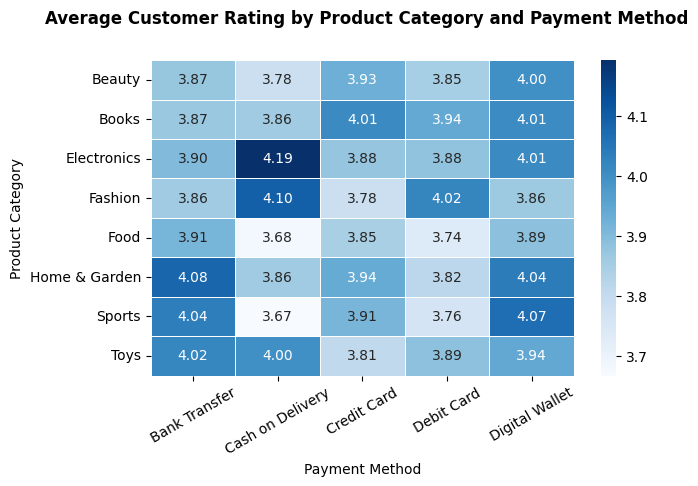

In [58]:
avg_rating_heatmap = (df_purchase_experience.pivot_table(values="Customer_Rating",index="Product_Category",columns="Payment_Method",aggfunc="mean"))

plt.figure(figsize=(7, 5))

sns.heatmap(avg_rating_heatmap,annot=True,cmap="Blues",fmt=".2f",linewidths=0.5)

plt.title("Average Customer Rating by Product Category and Payment Method", loc="left", fontsize=12, fontweight="bold", pad=15, x=-0.25, y=1.05)
plt.xlabel("Payment Method")
plt.xticks(rotation=30)
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

The heatmap shows that average customer ratings are mostly close to each other, usually between about 3.7 and 4.2. This suggests that customer rating does not strongly change across product category and payment method combinations.

A few combinations have slightly higher ratings, such as Electronics with Cash on Delivery and Sports with Digital Wallet. Some combinations are slightly lower, such as Sports with Cash on Delivery and Food with Cash on Delivery. Overall, the differences are small, so this pattern should not be overinterpreted.

#### **4.4 Bubble Plot Analysis**

In this step, a bubble plot is used to compare product categories using three numeric variables at the same time.

The x-axis shows average session duration, the y-axis shows average total amount, and the bubble size shows average pages viewed. Each bubble represents one product category.

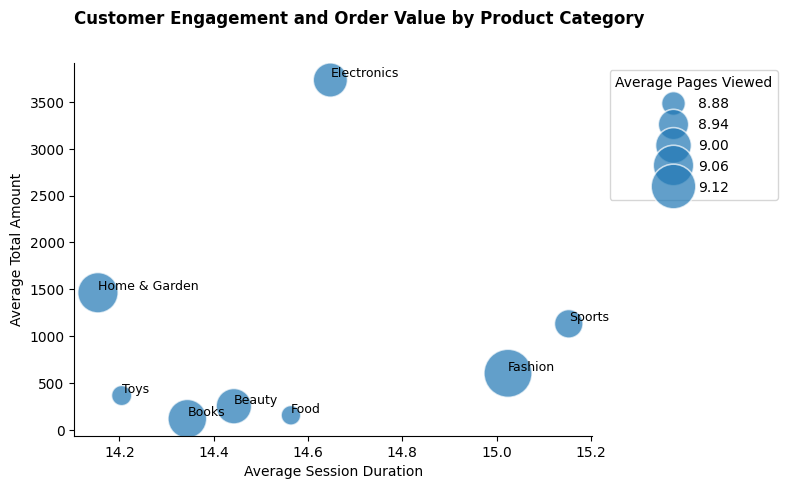

In [59]:
bubble_purchase = (df_purchase_experience.groupby("Product_Category").agg(
    avg_session_duration=("Session_Duration_Minutes", "mean"),
    avg_total_amount=("Total_Amount", "mean"),
    avg_pages_viewed=("Pages_Viewed", "mean")).reset_index())

plt.figure(figsize=(8, 5))

ax = sns.scatterplot(data=bubble_purchase,x="avg_session_duration",y="avg_total_amount",size="avg_pages_viewed",sizes=(200, 1200),alpha=0.7,legend="brief")

for i, row in bubble_purchase.iterrows():
    plt.text(
        row["avg_session_duration"],
        row["avg_total_amount"],
        row["Product_Category"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("Customer Engagement and Order Value by Product Category", loc="left", fontsize=12, y=1.05, fontweight="bold", pad=15)
plt.xlabel("Average Session Duration")
plt.ylabel("Average Total Amount")
plt.legend(title="Average Pages Viewed", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The bubble plot compares product categories based on average session duration, average total amount, and average pages viewed.

Electronics has the highest average total amount by far, even though its average session duration is not the highest. Home & Garden and Sports also have relatively higher average total amounts compared with the other categories.

Fashion and Sports have longer average session duration, but they do not have the highest order value. This suggests that longer session duration is not always connected to higher average total amount.

The bubble sizes are fairly similar across categories, which means average pages viewed does not change very strongly by product category. Overall, the plot shows that product category appears to explain order value more clearly than engagement metrics such as session duration or pages viewed.

#### **4.5 Principal Component Analysis**

In this step, Principal Component Analysis is used to reduce the numeric variables into a smaller number of components.

Before applying PCA, the numeric variables are scaled because PCA is affected by the size and scale of variables.

`Total_Amount` and `Customer_Rating` are not included as PCA input variables because they are important target-like variables. They can be used later for interpretation, but they should not be used to create the principal components.

In [60]:
pca_features_purchase = ["Age","Unit_Price","Quantity","Discount_Amount","Session_Duration_Minutes","Pages_Viewed","Delivery_Time_Days"]

pca_data_purchase = df_purchase_experience[pca_features_purchase].copy()

scaler_purchase = StandardScaler()
pca_scaled_purchase = scaler_purchase.fit_transform(pca_data_purchase)

pca_purchase = PCA()
pca_scores_purchase = pca_purchase.fit_transform(pca_scaled_purchase)

explained_variance_purchase = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca_features_purchase))],
    "Explained_Variance_Ratio": pca_purchase.explained_variance_ratio_,
    "Cumulative_Explained_Variance": pca_purchase.explained_variance_ratio_.cumsum()
})

explained_variance_purchase

,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.207310,0.207310
1,PC2,0.147779,0.355089
2,PC3,0.144284,0.499373
3,PC4,0.142629,0.642002
4,PC5,0.141216,0.783218
5,PC6,0.138296,0.921513
6,PC7,0.078487,1.000000


In [61]:
pca_loadings_purchase = pd.DataFrame(
    pca_purchase.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca_features_purchase))],
    index=pca_features_purchase
)
pca_loadings_purchase.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Age,-0.020,-0.302,0.687,-0.094,0.530,-0.383,0.017
Unit_Price,0.705,0.012,-0.005,-0.042,0.043,-0.018,-0.706
Quantity,0.017,-0.238,-0.150,0.936,0.210,-0.020,-0.029
Discount_Amount,0.707,0.011,-0.001,0.007,0.023,0.013,0.707
Session_Duration_Minutes,-0.019,0.595,0.352,0.142,0.351,0.615,-0.014
Pages_Viewed,0.021,0.532,0.364,0.291,-0.487,-0.513,-0.006
Delivery_Time_Days,-0.040,0.464,-0.499,-0.096,0.559,-0.461,0.022


The PCA results show that PC1 explains about 20.7% of the total variance. PC1 is mainly related to `Unit_Price` and `Discount_Amount`, so it appears to represent a price/discount dimension.

PC2 explains about 14.8% of the total variance. PC2 is mostly related to `Session_Duration_Minutes`, `Pages_Viewed`, and `Delivery_Time_Days`, so it appears to represent a customer engagement and delivery-time dimension.

Together, PC1 and PC2 explain about 35.5% of the total variance. This means the first two principal components do not capture most of the information in the numeric variables. About six components are needed to explain over 90% of the variance.

Overall, PCA can help summarize the data, but Dataset 4 does not reduce very strongly into only one or two components.

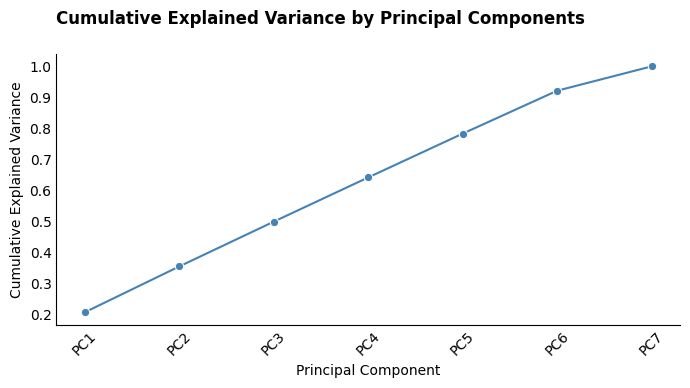

In [62]:
plt.figure(figsize=(7, 4))

ax = sns.lineplot(data=explained_variance_purchase,x="Principal_Component",y="Cumulative_Explained_Variance",marker="o",color="steelblue")

ax.set_title("Cumulative Explained Variance by Principal Components", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Cumulative Explained Variance")
ax.tick_params(axis="x", rotation=45, length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
pca_scores_df_purchase = pd.DataFrame(pca_scores_purchase[:, :2], columns=["PC1", "PC2"], index=df_purchase_experience.index)

pca_scores_df_purchase["total_amount"] = df_purchase_experience["Total_Amount"]
pca_scores_df_purchase["Customer_Rating"] = df_purchase_experience["Customer_Rating"]
pca_scores_df_purchase["product_category"] = df_purchase_experience["Product_Category"]

pca_scores_df_purchase.head()

,PC1,PC2,total_amount,Customer_Rating,product_category
0,-0.553473,0.842714,54.28,5,Toys
1,-0.431042,-1.837817,244.90,3,Toys
2,-0.557281,-1.606976,240.75,2,Food
3,2.055361,-0.672077,574.78,4,Electronics
4,0.109984,0.095172,3778.05,4,Sports


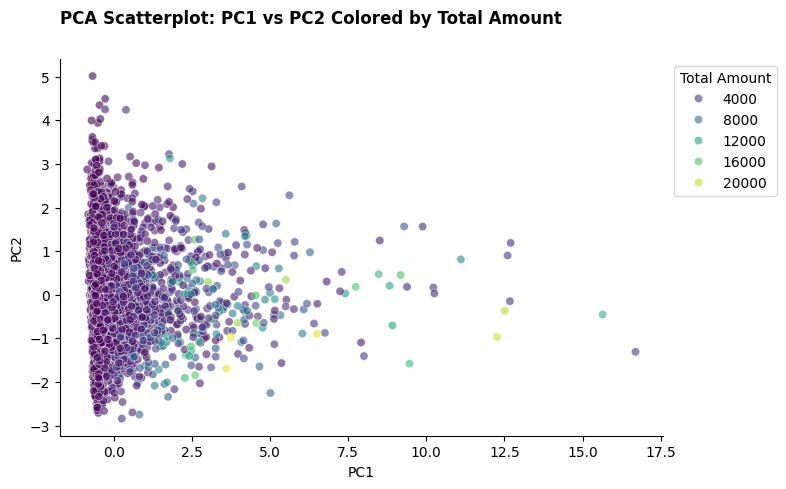

In [64]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="total_amount",alpha=0.6, palette="viridis")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Total Amount", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Total Amount", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

The PCA scatterplot colored by total amount shows that higher-value orders are more visible on the positive side of PC1. This makes sense because PC1 is mostly related to `Unit_Price` and `Discount_Amount`.

Most orders are still concentrated near the left and middle of the plot, so PC1 and PC2 do not fully separate high-value and low-value orders. However, the plot suggests that PC1 is useful for identifying higher order-value patterns.

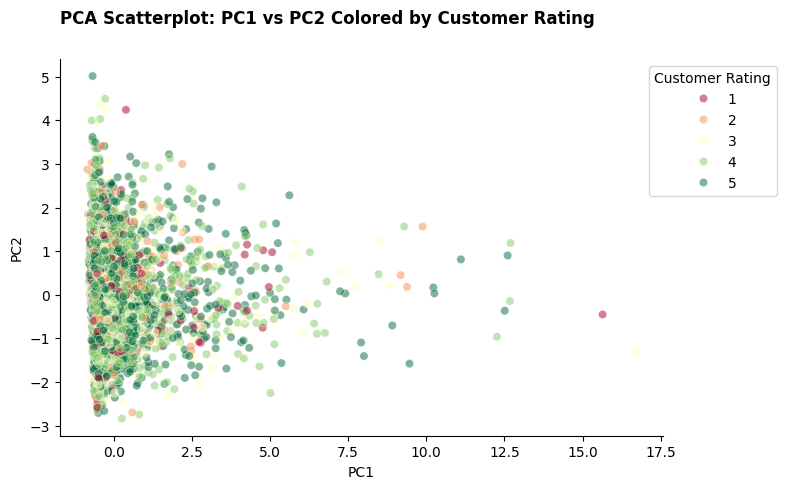

In [65]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="Customer_Rating",alpha=0.5, palette = "RdYlGn")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Customer Rating", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Customer Rating", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

The PCA scatterplot colored by customer rating shows strong overlap between rating levels. Ratings from 1 to 5 appear mixed across the PCA space.

This suggests that the first two principal components do not clearly separate customers by satisfaction rating. Customer rating may not be strongly explained by these numeric variables in a two-dimensional PCA view.

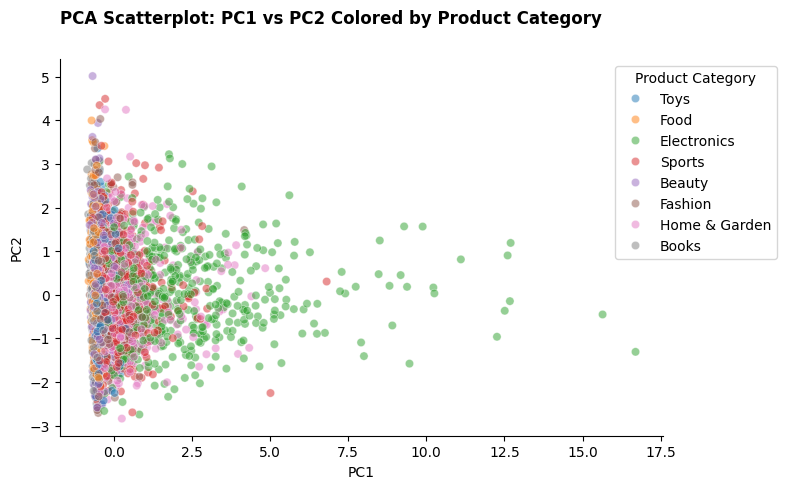

In [66]:
plt.figure(figsize=(8,5))
#pca_sample_purchase = pca_scores_df_purchase.sample(3000, random_state=42)
ax = sns.scatterplot(data=pca_scores_df_purchase,x="PC1",y="PC2",hue="product_category",alpha=0.5, palette="tab10")  

plt.title("PCA Scatterplot: PC1 vs PC2 Colored by Product Category", loc="left", fontsize=12, fontweight="bold", pad=12, y=1.05)
plt.xlabel("PC1")
plt.ylabel("PC2")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(title="Product Category", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

The PCA scatterplot colored by product category shows that Electronics appears more often on the positive side of PC1. Based on the PCA loadings, PC1 is mainly related to `Unit_Price` and `Discount_Amount`.

This suggests that product category is associated with the price/discount pattern captured by PC1, especially for Electronics. In other words, Electronics seems to have a different numeric profile from many other categories because it tends to have higher price-related values.

However, most other product categories overlap heavily, so PCA does not clearly separate all categories. This relationship should be interpreted as an association, not causation.

#### **4.6 Linear Regression Analysis**

In this step, linear regression is used with the strongest correlated numeric variables.

Each variable is tested once as the target variable, while the other selected variables are used as predictors. This helps compare which numeric variables are easier or harder to predict based on the selected relationships.

The goal is to check predictive relationships, not to prove causation.

In [67]:
# Linear regression using the strongest correlated numeric variables

variables_purchase = ["Unit_Price","Quantity","Discount_Amount","Total_Amount"]

regression_data_purchase = df_purchase_experience[variables_purchase].copy()

results_purchase = []

for target in variables_purchase:
    
    predictors = [col for col in variables_purchase if col != target]
    
    X = regression_data_purchase[predictors]
    y = regression_data_purchase[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = model.score(X_test, y_test)
    mse = mean_squared_error(y_test, y_pred)
    
    results_purchase.append({
        "target": target,
        "predictors": predictors,
        "test_r2_score": r2,
        "test_mse": mse})

regression_results_purchase = pd.DataFrame(results_purchase)

regression_results_purchase

,target,predictors,test_r2_score,test_mse
0,Unit_Price,"[Quantity, Discount_Amount, Total_Amount]",0.744812,97714.109874
1,Quantity,"[Unit_Price, Discount_Amount, Total_Amount]",0.280452,1.275602
2,Discount_Amount,"[Unit_Price, Quantity, Total_Amount]",0.155414,3533.299534
3,Total_Amount,"[Unit_Price, Quantity, Discount_Amount]",0.741009,564531.402661


The linear regression results show that `Unit_Price` and `Total_Amount` have the strongest predictive relationships among the selected numeric variables.

`Unit_Price` has a test R2 score of about 0.74, which means it can be predicted fairly well using `Quantity`, `Discount_Amount`, and `Total_Amount`. `Total_Amount` also has a test R2 score of about 0.74, which means it can be predicted fairly well using `Unit_Price`, `Quantity`, and `Discount_Amount`.

This result makes sense because `Total_Amount` is closely related to price, quantity, and discount. It also supports the earlier correlation heatmap, where `Unit_Price` and `Total_Amount` had one of the strongest relationships.

`Quantity` has a much lower R2 score of about 0.28, and `Discount_Amount` has the lowest R2 score of about 0.16. This suggests that these variables are harder to predict using the other selected variables.

Overall, the strongest predictive patterns in Dataset 4 are related to order value and price-based variables. The MSE values should not be directly compared across all targets because each target variable has a different scale.

#### **4.7 Final Week 9 Conclusion for Dataset 4**

The Week 9 analysis shows that Dataset 4 has useful relationships, especially around order value and price-related variables.

The correlation heatmap showed that `Unit_Price`, `Discount_Amount`, `Quantity`, and `Total_Amount` have the clearest relationships. Other variables, such as `Customer_Rating`, `Session_Duration_Minutes`, `Pages_Viewed`, and `Delivery_Time_Days`, showed weaker numeric relationships.

The grouped heatmaps showed that some product-device and product-payment combinations have small differences. The relative total amount heatmap was especially useful because it compared each product category with its own average instead of only using raw order value.

The bubble plot showed that product categories differ in average order value and customer engagement. Electronics had the highest average total amount, but longer session duration or more pages viewed did not always mean higher order value.

The PCA results showed that the first two principal components explained only about 35.5% of the total variance. PC1 was mostly related to price and discount variables, while PC2 was more related to engagement and delivery variables. This means PCA helped summarize the data, but Dataset 4 does not reduce strongly into only one or two components.

The PCA scatterplots showed that high-value orders and Electronics products appeared more often on the positive side of PC1. This suggests that PC1 captures a price/discount pattern that is related to higher order values and some product category differences. However, most categories still overlapped, so PCA did not create clear separate clusters.

The linear regression results supported the earlier correlation findings. `Unit_Price` and `Total_Amount` were easier to predict than `Quantity` and `Discount_Amount`. This shows that the strongest predictive patterns in Dataset 4 are related to order value and price-based variables.

Overall, Dataset 4 is useful for understanding purchase value, product category behavior, and customer journey patterns. However, customer rating and engagement variables showed weaker relationships, so they may be harder to predict with simple numeric analysis alone.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

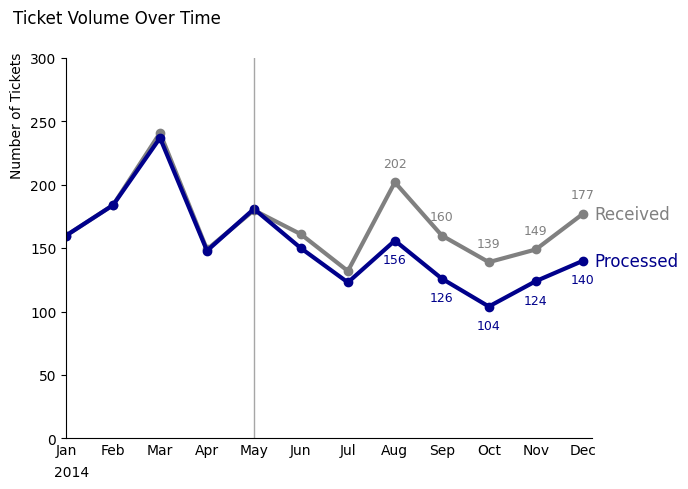

In [68]:
# Approximate data from the Ticket Trend graph
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

received = [160, 184, 241, 149, 180, 161, 132, 202, 160, 139, 149, 177]
processed = [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]

plt.figure(figsize=(7, 5))

# Lines for received and processed tickets
plt.plot(months, received, marker="o", linewidth=3,color="gray", label="Received")
plt.plot(months, processed, marker="o", linewidth=3, color= "darkblue", label="Processed")

# Y-axis and X-axis start at zero
plt.ylim(0, 300)
plt.yticks([0, 50, 100, 150, 200, 250, 300])
plt.xlim(0, 11.2)
plt.xticks([i for i in range(12)], months)

# Vertical line around May
plt.axvline(x=4, color="gray", linewidth=1, alpha=0.7)

# Remove x-axis ticks
plt.tick_params(axis="x", length=0)

# Title and labels
plt.title("Ticket Volume Over Time", loc="left", fontsize=12, pad=25 , x = -0.1)
plt.xlabel("2014", fontsize=10)
plt.ylabel("Number of Tickets")

# Adjust label positions
plt.gca().yaxis.set_label_coords(-0.08, 0.85)
plt.gca().xaxis.set_label_coords(0.01,-0.07)

# Direct labels at the end of the lines
plt.text(11.25, received[-1], "Received", color="gray", fontsize=12, va="center")
plt.text(11.25, processed[-1], "Processed", color="darkblue", fontsize=12, va="center")

# Show selected data labels from Aug to Dec
for i in range(7, 12):
    plt.text(i, received[i] + 12, str(received[i]), color="gray", ha="center", fontsize=9)
    plt.text(i, processed[i] - 18, str(processed[i]), color="darkblue", ha="center", fontsize=9)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()